# MoodMix: Initial EDA

Disclaimer: 
- If your plan is to scrape data, you are to acquire minimally 500 rows of data (the more the better), and populate this template with your current available data.
- If you're working with non-tabular data like images and audio, you are to engineer your own features and populate this template. Focus more on structure and meta-data analysis, then perform image specifc (pixel intensity, colour analysis, etc) or audio specific (signal-to-noise, zero-crossing rate) data quality metrics instead of just "missing or mismatching rows"
- If you are working with Reinforcement learning, don't use this template at all, consult Supa-att for what you need to show for your specific RL agent.

### Project context

MoodMix matches how a user says they feel (*"I'm going through a breakup"*) to songs. The user's prompt and every song each get a 0–1 score for ~10 named moods (called **mood dimensions** in this notebook), and songs are ranked by cosine similarity to the prompt.

- **Prompt model** (reads the user's text): trained on **EmpatheticDialogues**.
- **Song model** (reads a song's lyrics): trained on **MuSe** songs, labelled with the mood word that found each song (its "seed"). Lyrics come from **LRCLIB**.

"Stage 1–4" refer to the proposal's workflow: 1 choose the moods, 2 song model, 3 prompt model, 4 match and evaluate. This EDA is Stage 1 (Milestone 1).


### Setup

In [1]:
import ast
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

DATA = Path("../data/raw")

# One accent colour for single-series charts, a muted grey for context, a single-hue ramp for magnitude.
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#b5b3ad"
INK, MUTED = "#0b0b0b", "#898781"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "font.size": 9, "legend.frameon": False,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

## Dataset for Prompt Encoding: EmpatheticDialogues

### 1. Summarise the background of the dataset(s) which you're using, and how they contribute to your project [limited to 100 words per dataset]

**Response.**

EmpatheticDialogues has 24,850 conversations written by crowdworkers. Each writer picked one of 32 emotions, described a situation from their own life where they felt it, then talked about it with another worker. 

The situation text (*"My dog died and I was just heartbroken"*) is short, first-person and about a life event, which makes it the relevant to what our users might type (*"I'm going through a breakup"*). We will use this to train and test the prompt model.

#### Loading the raw files

The authors split the dataset into three CSVs. We combine all three for ease of analysis.

Each row is an **utterance** which is a turn in one conversation, so each conversation spans 1–8 rows. 

Our unit of analysis is the **situation**. Our "situation" comes from the 'prompt' the speaker wrote. Situation is one per conversation. Therefore, one row -> one conversation.

In [2]:
ED_COLS = ["conv_id", "utterance_idx", "context", "prompt", "speaker_idx", "utterance", "selfeval", "tags"]
ED_SPLITS = ["train", "valid", "test"]


def read_ed(split):
    return pd.read_csv(DATA / "empatheticdialogues" / f"{split}.csv", names=ED_COLS, header=0,
                       usecols=range(8), quoting=csv.QUOTE_NONE, dtype=str, keep_default_na=False
                       ).assign(split=split)


utt = pd.concat([read_ed(s) for s in ED_SPLITS], ignore_index=True)
utt["utterance_idx"] = utt["utterance_idx"].astype(int)
for col in ["prompt", "utterance"]:
    utt[col] = utt[col].str.replace("_comma_", ",", regex=False)

# One row per conversation (= one situation): its first utterance.
ed = (utt.loc[utt.groupby("conv_id")["utterance_idx"].idxmin()] # get first utterance
         .sort_index()
         .rename(columns={"context": "emotion", "prompt": "situation", "utterance": "first_utterance"})
         [["split", "conv_id", "emotion", "situation", "first_utterance"]]
         .reset_index(drop=True))
ed["n_words"] = ed["situation"].str.split().str.len()

ed.head()

,split,conv_id,emotion,situation,first_utterance,n_words
0,train,hit:0_conv:1,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. ...,25
1,train,hit:1_conv:2,afraid,i used to scare for darkness,it feels like hitting to blank wall when i see the darkness,6
2,train,hit:1_conv:3,proud,I showed a guy how to run a good bead in welding class and he caught on quick.,Hi how are you doing today,18
3,train,hit:2_conv:4,faithful,I have always been loyal to my wife.,I have never cheated on my wife.,8
4,train,hit:2_conv:5,terrified,A recent job interview that I had made me feel very anxious because I felt like I didn't come prepared.,"Job interviews always make me sweat bullets, makes me uncomfortable in general to be looked at under a microscope li...",20


### 2. State the size of your dataset(s)

In [3]:
ed_dir = DATA / "empatheticdialogues"
size = pd.DataFrame({
    "file MB": {s: round((ed_dir / f"{s}.csv").stat().st_size / 1e6, 1) for s in ED_SPLITS},
    "utterances": utt["split"].value_counts(),
    "situations": ed["split"].value_counts(),
}).loc[ED_SPLITS]
size.loc["total"] = size.sum()
display(size)
print(f"utterance table: {utt.shape[0]:,} rows x {len(ED_COLS)} columns")
print(f"situation table: {ed.shape[0]:,} rows; {ed['situation'].nunique():,} unique situation texts")
print(f"emotion labels: {ed['emotion'].nunique()}; crowdworker IDs: {utt['speaker_idx'].nunique()}")
print(f"utterances per conversation: {utt.groupby('conv_id').size().describe()[['min', '50%', 'max']].to_dict()}")

,file MB,utterances,situations
train,17.4,84169.0,19533.0
valid,38.9,12078.0,2770.0
test,36.6,10973.0,2547.0
total,92.9,107220.0,24850.0


utterance table: 107,220 rows x 8 columns
situation table: 24,850 rows; 24,503 unique situation texts
emotion labels: 32; crowdworker IDs: 810
utterances per conversation: {'min': 1.0, '50%': 4.0, 'max': 8.0}


**Response.**

- **Raw files:** 107,220 utterances × 8 columns
- **Situation table (what we analyse and train on):** **24,850 rows**, one per conversation. 24,503 of the situation texts are unique.
- **32 emotion labels**, 810 crowdworker IDs, 1–8 utterances per conversation (median 4).

### 3. For each feature of your dataset, describe what it represents and its data type (numerical, categorical, unstructured string, etc)

**Response.**

| Feature | Table | What it represents | Data type |
|---|---|---|---|
| `conv_id` | both | ID of the conversation, e.g. `hit:0_conv:1` | categorical (ID) |
| `utterance_idx` | raw | turn number inside the conversation (1–8) | numerical, ordinal integer |
| `context` → **`emotion`** | both | the emotion the writer picked before writing. **Our label** | categorical, 32 levels |
| `prompt` → **`situation`** | both | the writer's description of a time they felt that emotion. **Our model input** | unstructured string |
| `speaker_idx` | raw | anonymised ID of the crowdworker who wrote the utterance | categorical (ID), 810 levels |
| `utterance` | raw | one turn of the dialogue | unstructured string |
| `selfeval` | raw | the two workers' 1–5 ratings of the conversation after it ended, e.g. `5\|5\|5_2\|2\|5` (three ratings per worker, workers separated by `_`) | string encoding 6 ordinal ratings |
| `tags` | raw | flags on a few utterances: `<UNIGRAM>`, `<HI>`, `<POLITICAL>`, `<NUMERAL>` | categorical (space-separated flags) |
| `split` | both (added) | which file the row came from: train / valid / test | categorical, 3 levels |
| `first_utterance` | derived | the first turn of the dialogue, usually the writer retelling the situation | unstructured string |
| `n_words` | derived | number of words in `situation` | numerical, integer |

In [4]:
display(utt.dtypes.rename("raw dtype").to_frame().T)
utt.head(3)

,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,split
raw dtype,str,int64,str,str,str,str,str,str,str


,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,split
0,hit:0_conv:1,1,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",1,I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. ...,5|5|5_2|2|5,,train
1,hit:0_conv:1,2,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",0,"Was this a friend you were in love with, or just a best friend?",5|5|5_2|2|5,,train
2,hit:0_conv:1,3,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",1,This was a best friend. I miss her.,5|5|5_2|2|5,,train


### 4. For each feature, determine percentage of missing data. Describe how you're planning on resolving the missing data. State any assumptions you make

In [5]:
def pct_missing(df):
    """NaN or blank text counts as missing."""
    blank = df.apply(lambda c: c.isna() | c.astype(str).str.strip().eq(""))
    return (blank.mean() * 100).round(2)

display(pd.concat({"utterance table": pct_missing(utt[ED_COLS]),
                   "situation table": pct_missing(ed)}, axis=1))

short = ed[ed["n_words"] <= 3]
print(f"situations with <= 3 words: {len(short)} ({len(short) / len(ed):.2%})")
print("situations with no letters at all (e.g. '1'):", (~ed["situation"].str.contains("[A-Za-z]")).sum())
short[["emotion", "situation"]].head(12)

,utterance table,situation table
conv_id,0.00,0.0
utterance_idx,0.00,NaN
context,0.00,NaN
prompt,0.00,NaN
speaker_idx,0.00,NaN
utterance,0.00,NaN
selfeval,0.00,NaN
tags,99.15,NaN
split,NaN,0.0
emotion,NaN,0.0


situations with <= 3 words: 146 (0.59%)
situations with no letters at all (e.g. '1'): 21


,emotion,situation
147,anticipating,waiting for christmas!
222,angry,Lies
498,sad,1
663,devastated,I am devasted.
801,proud,2
958,disappointed,1
1403,prepared,ready to move
1585,proud,Graduating High School!
1771,sad,I ma devastated.
2080,sentimental,1


**Response.**

- **There are no NaNs in the raw table.** The only column with real gaps is `tags` (99.15% empty), because it is only set on a few flagged utterances. We don't use it, so nothing needs resolving.
- **Every situation has text, but some are effectively missing.** 146 situations (0.59%) have ≤ 3 words. Most are still meaningful (*"Failing Algebra"*, *"My marriage"*, *"Lies"*), but **21 contain no letters at all** (`1`, `2`) and carry no information.
- **Plan:** drop the 21 situations with no letters and keep the other short ones, since real users also type short prompts.
- **Assumption:** the label of a placeholder situation can't be checked against its text, so dropping these loses nothing.

### 5. For each feature, identify outliers or mismatched data. Describe how you plan to handle them. Clearly state any assumption you made.

In [6]:
# 1) The same situation text more than once
dup = ed[ed.duplicated("situation", keep=False)]
per_text = dup.groupby("situation").agg(n=("emotion", "size"), labels=("emotion", "nunique"),
                                        splits=("split", "nunique"))
print(f"rows with a repeated situation: {len(dup)} ({per_text.shape[0]} distinct texts)")
print(f"  texts with conflicting labels: {(per_text['labels'] > 1).sum()}")
print(f"  texts appearing in more than one split (train/test leakage): {(per_text['splits'] > 1).sum()}")
display(dup[dup["situation"].isin(per_text.index[per_text["labels"] > 1])]
        .sort_values("situation")[["situation", "emotion", "split"]].head(8))

# 2) Length outliers (1.5 x IQR rule)
q1, q3 = ed["n_words"].quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print(f"length IQR fence: > {upper:.0f} words -> {(ed['n_words'] > upper).sum()} situations "
      f"({(ed['n_words'] > upper).mean():.1%}); longest = {ed['n_words'].max()} words")

# 3) Text-level oddities
print("non-ASCII situations:", ed["situation"].str.contains(r"[^\x00-\x7F]").sum())
print("leading/trailing whitespace:", (ed["situation"] != ed["situation"].str.strip()).sum())
print("all-lowercase start:", ed["situation"].str.strip().str.match(r"[a-z]").sum())

# 4) Label vs text mismatches: one event under many labels, and a label the text doesn't show
display(ed.loc[ed["situation"].str.contains("bought a new car|brother was working in my office", case=False),
               ["emotion", "situation"]])

# 5) Labels that aren't music moods. A first rough grouping of the 32 labels; Stage 1 fixes the final mapping.
MUSIC_MOODS = {"sad", "devastated", "lonely", "nostalgic", "sentimental", "hopeful", "anxious",
               "joyful", "content", "excited", "afraid"}
NOT_MUSIC = {"guilty", "ashamed", "jealous", "embarrassed", "disgusted", "impressed", "prepared",
             "faithful", "trusting"}
not_music = ed["emotion"].isin(NOT_MUSIC)
print(f"situations under the {len(NOT_MUSIC)} non-music labels: {not_music.sum():,} ({not_music.mean():.0%})")

rows with a repeated situation: 534 (187 distinct texts)
  texts with conflicting labels: 78
  texts appearing in more than one split (train/test leakage): 4


,situation,emotion,split
10948,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
10940,"I hate scary movies, they scare me so much, especially jumpscares",afraid,train
10937,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
10923,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
5642,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",terrified,train
4050,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",angry,train
3752,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",afraid,train
3721,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",afraid,train


length IQR fence: > 41 words -> 838 situations (3.4%); longest = 136 words
non-ASCII situations: 5
leading/trailing whitespace: 2055
all-lowercase start: 2376


,emotion,situation
1281,excited,I bought a new car a few days ago. It's really sleek and fun to drive
3664,impressed,My friend just bought a new car and I can't believe how cheap he got it for.
4402,sentimental,My brother was working in my office
6312,jealous,My friend bought a new car.
7826,impressed,Just bought a new car and I'm surprised at how well it drives.
8700,grateful,I just bought a new car because of my new job and I am very happy
14700,jealous,My best friend just bought a new car. It's hard not to be a bit envious when my car is a 2006
16299,jealous,My neighbours just bought a new car and put in a pool. I feel like I just can't get ahead- I can barely pay the bills.
20617,jealous,My neighbor bought a new car. Now I really want one myself.
20702,jealous,A friend of mine bought a new car. It was a model I had my eye on for some time


situations under the 9 non-music labels: 6,372 (26%)


**Response.**

**1. Duplicate situations.** 534 rows share their situation text with at least one other row (187 distinct texts). Usually the same writer reused one situation for several conversations.
- **78 of those texts have conflicting labels.** For example, *"I used to be afraid of the dark…"* is labelled afraid, terrified and angry.
- **4 texts appear in more than one split**, so the same text would be in both training and test data.
- *Plan:* keep one row per text with its majority label, and drop texts whose labels tie. Put all copies of a text in the same split.

**2. Length outliers.** The 1.5 × IQR fence is 41 words. 838 situations (3.4%) are above it; the longest has 136 words.
- *Plan:* keep them. They are genuine long descriptions, and 136 words is well below the 256-token limit of the sentence-transformer encoder.

**3. Formatting.**
- 2,055 situations have leading or trailing whitespace, and 2,376 start in lower case.
- 5 contain non-ASCII characters, and there are typos (*"I am devasted"*, *"I ma devastated"*).
- *Plan:* strip whitespace. Keep case and typos.
- *Assumption:* users type like this too, and the pretrained encoder copes with it.

**4. Labels that don't match the text.** The writer chose the label and nobody checked it.
- The same event gets very different labels depending on the writer's point of view. *"…bought a new car"* is labelled excited, grateful, jealous and impressed.
- Some pairs look like noise (*"My brother was working in my office"* → sentimental).
- *Plan:* the data can't fix this. Treat each label as "this dimension is high", not "the others are zero". Report results per dimension, and optionally add Jev scores across all dimensions.

**5. Labels that aren't music moods.** 9 labels (guilty, ashamed, jealous, embarrassed, disgusted, impressed, prepared, faithful, trusting) cover 6,372 situations (26%). They get mapped or dropped when we fix the dimensions (Stage 1).

### 6. For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

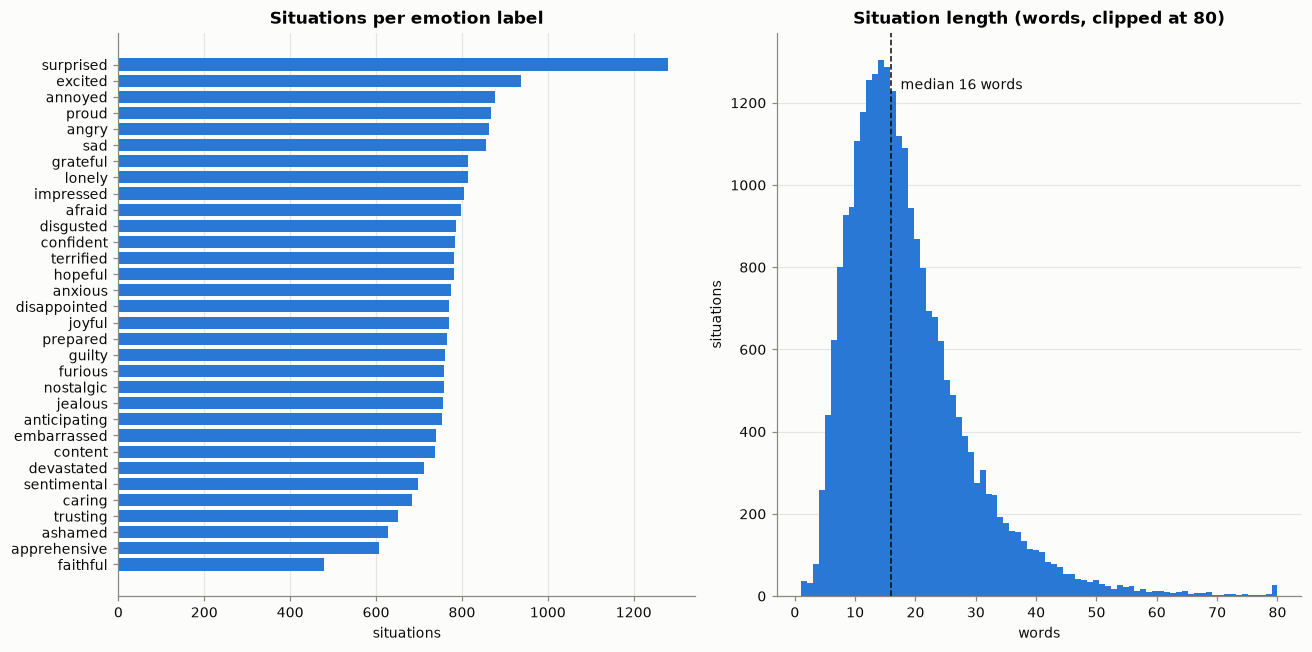

label counts: min 478 (faithful), max 1279 (surprised), median 770
start in the first person: 76%
mention music/songs: 116


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1.1, 1]})

counts = ed["emotion"].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=BLUE, height=0.75)
axes[0].set_title("Situations per emotion label")
axes[0].set_xlabel("situations")
axes[0].grid(axis="y", visible=False)

axes[1].hist(ed["n_words"].clip(upper=80), bins=80, color=BLUE)
med = ed["n_words"].median()
axes[1].axvline(med, color=INK, lw=1, ls="--")
axes[1].annotate(f"median {med:.0f} words", (med, axes[1].get_ylim()[1] * .9), xytext=(6, 0),
                 textcoords="offset points", color=INK)
axes[1].set_title("Situation length (words, clipped at 80)")
axes[1].set_xlabel("words")
axes[1].set_ylabel("situations")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

first_person = ed["situation"].str.match(r"(?i)^\s*(?:i|i'm|i've|i'd|i'll|my|me|we|we're|our|us)\b")
print(f"label counts: min {counts.min()} ({counts.idxmin()}), max {counts.max()} ({counts.idxmax()}), "
      f"median {counts.median():.0f}")
print(f"start in the first person: {first_person.mean():.0%}")
music_mentions = ed["situation"].str.contains(r"(?i)\b(?:music|songs?)\b").sum()
print(f"mention music/songs: {music_mentions}")

**Response.**

**Emotion label.**
- The labels are fairly balanced, from 478 (*faithful*) to 1,279 (*surprised*), median 770. Only *surprised* stands out, at about 1.7× the median, so no resampling is needed.

**Situation length.**
- Lengths are right-skewed: median **16 words**, 80% between 8 and 32 words.
- **76% start in the first person** ("I", "my", "we"…), which matches how a user would describe their mood.

**Content.** Only 116 situations mention music or songs. They describe life events, not music requests. That is fine for learning what a prompt means, but it means our own hand-written prompts are needed as the real test.

**Split** (Q2): 79 / 11 / 10%.

### 7. Perform bi-variate analysis on some of the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables.

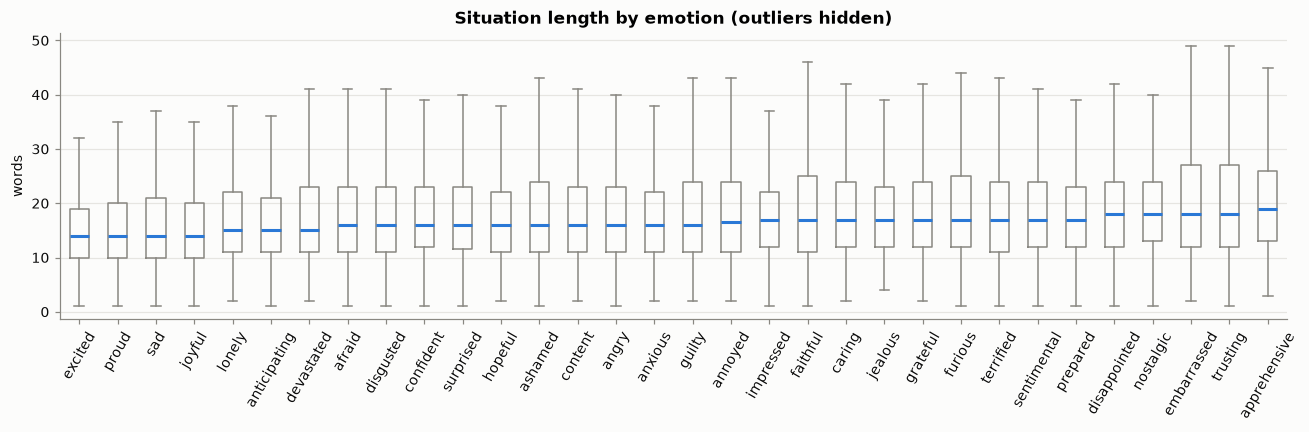

In [36]:
# Emotion x situation length
order = ed.groupby("emotion")["n_words"].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([ed.loc[ed["emotion"] == e, "n_words"] for e in order], tick_labels=order, showfliers=False,
           medianprops={"color": BLUE, "lw": 2}, boxprops={"color": MUTED}, whiskerprops={"color": MUTED},
           capprops={"color": MUTED})
ax.set_title("Situation length by emotion (outliers hidden)")
ax.set_ylabel("words")
ax.tick_params(axis="x", rotation=60)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

share of all situations mentioning each theme:


,family,work / job,friends,school / exams,pets,celebrations / trips,money,death / loss,breakup,music
%,18.8,10.7,9.0,8.1,6.2,6.0,2.8,2.4,1.7,1.0


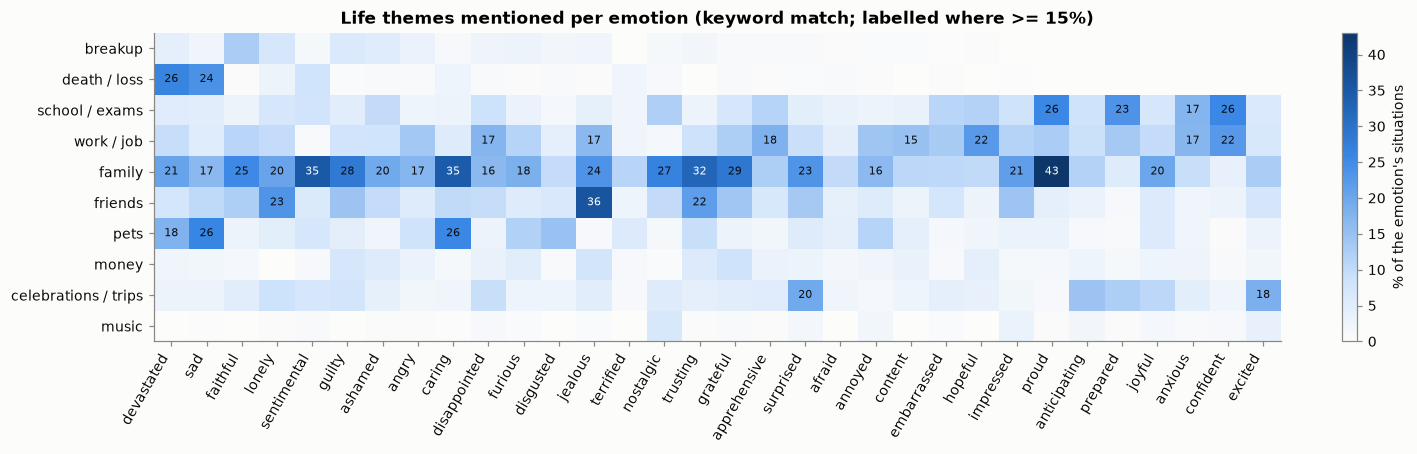

In [37]:
# Emotion x life theme: which situations does each emotion come from?
THEMES = {
    "breakup": r"\b(?:break ?ups?|broke up|dumped|divorc\w*|my ex|cheat\w*)\b",
    "death / loss": r"\b(?:died|dies|dying|death|passed away|funeral)\b",
    "school / exams": r"\b(?:exams?|tests?|school|college|university|grades?|class)\b",
    "work / job": r"\b(?:job|work|boss|promot\w*|fired|hired|interview)\b",
    "family": r"\b(?:mom|dad|mother|father|brother|sister|son|daughter|parents?|kids?|wife|husband)\b",
    "friends": r"\b(?:friends?|buddy)\b",
    "pets": r"\b(?:dogs?|cats?|pets?|puppy|kitten)\b",
    "money": r"\b(?:money|bills?|rent|debt|paycheck|afford)\b",
    "celebrations / trips": r"\b(?:birthday|christmas|vacation|holiday|wedding|party|trip)\b",
    "music": r"\b(?:music|songs?|concert|band)\b",
}
text = ed["situation"].str.lower()
theme_hits = pd.DataFrame({t: text.str.contains(p) for t, p in THEMES.items()})
print("share of all situations mentioning each theme:")
display((theme_hits.mean() * 100).round(1).sort_values(ascending=False).to_frame("%").T)

share = theme_hits.groupby(ed["emotion"]).mean().T * 100
share = share[share.loc[["death / loss", "breakup"]].sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(share.values, cmap=BLUES, aspect="auto")
ax.set_xticks(range(share.shape[1]), share.columns, rotation=60, ha="right")
ax.set_yticks(range(share.shape[0]), share.index)
ax.grid(False)
for i, j in zip(*np.where(share.values >= 15)):
    ax.text(j, i, f"{share.values[i, j]:.0f}", ha="center", va="center", fontsize=7,
            color="white" if share.values[i, j] > 30 else INK)
fig.colorbar(im, ax=ax, label="% of the emotion's situations", fraction=0.025)
ax.set_title("Life themes mentioned per emotion (keyword match; labelled where >= 15%)")
plt.tight_layout()
plt.show()

In [10]:
# Emotion x vocabulary: the most distinctive words for the music-mood labels
STOP = set("""a about after again all also am an and any are as at be because been before being but by can
could did do does doing don't for from get got had has have having he her him his how i i'm i've if in
into is it it's its just me more my myself no not now of on one or other our out over really she so some
than that the their them then there they this to too up very was we went were what when which while who
will with would you your""".split())


def words(s):
    return [w for w in re.findall(r"[a-z']+", s.lower()) if w not in STOP and len(w) > 2]


per_emotion = {e: Counter(w for s in grp for w in words(s)) for e, grp in ed.groupby("emotion")["situation"]}
overall = sum(per_emotion.values(), Counter())
n_all = sum(overall.values())


def distinctive(e, k=8, min_count=15):
    c, n_e = per_emotion[e], sum(per_emotion[e].values())
    lift = {w: (c[w] / n_e) / (overall[w] / n_all) for w in c if overall[w] >= min_count and c[w] >= 5}
    return ", ".join(sorted(lift, key=lift.get, reverse=True)[:k])


pd.DataFrame({"most distinctive words (lift vs all situations)":
              {e: distinctive(e) for e in sorted(MUSIC_MOODS)}})

,most distinctive words (lift vs all situations)
afraid,"dark, ghost, frightened, terrified, windows, sounds, creepy, gun"
anxious,"stressed, anxious, nervous, dentist, anxiety, what's, nerve, uneasy"
content,"relaxed, shining, relaxing, satisfied, content, relax, peaceful, sun"
devastated,"crushed, heartbroken, destroyed, devastated, distraught, flooded, fire, died"
excited,"pumped, stoked, thrilled, amusement, ecstatic, cruise, smash, bros"
hopeful,"optimistic, fingers, hopeful, crossed, praying, pray, crossing, positive"
joyful,"joyful, happiness, proposed, birth, ecstatic, happy, born, yes"
lonely,"isolated, bored, lonely, alone, empty, quiet, boring, nobody"
nostalgic,"reminded, reminds, album, childhood, memories, pokemon, albums, holidays"
sad,"distraught, cried, depressed, bummed, unhappy, turtle, died, devastated"


**Response.**

**1. Emotion × situation length (box plot).**
- Median length only ranges from 14 words (*excited, proud, sad, joyful*) to 19 (*apprehensive*), and the boxes overlap almost completely.
- So length says almost nothing about the emotion, and a model can't cheat by using length. No correction is needed.

**2. Emotion × life theme (heatmap, keyword matches).** Which kinds of event lead to which emotion:
- **Death/loss** is concentrated in *devastated* (26%) and *sad* (24%). **Pets** are in *sad* and *caring* (26% each). So a "sadness" dimension will mostly learn from grief.
- **School/exams** go with *proud*, *confident* (26%) and *prepared* (23%). **Work/job** goes with *confident* and *hopeful* (22%). These are achievement and stress moods.
- **Family** is the most common theme overall (19% of all situations) and appears under almost every emotion, so it doesn't indicate any one mood.
- **Breakups are rare**: only 428 situations (1.7%), spread over *faithful*, *lonely* and *guilty*. Our motivating example ("I'm going through a breakup") is under-represented, so our own test prompts need to cover it.

**3. Emotion × vocabulary (most distinctive words for the 11 music-mood labels).**
- The words match the labels: *lonely* → isolated, alone, empty, quiet; *nostalgic* → reminded, childhood, memories, album; *anxious* → stressed, nervous, dentist; *devastated* → heartbroken, crushed, died.
- So the text carries the label, and it should be learnable.
- Some labels share words, which makes them candidates for merging into one dimension:
  - *nostalgic* and *sentimental* (photos, albums, "nostalgic")
  - *sad* and *devastated* (distraught, died, devastated), the same feeling at two intensities

### 8. Provide relevant summary statistics for the features you're planning to use. Briefly explain why you may or may not use certain variables.

In [11]:
display(ed[["split", "emotion"]].describe())
display(ed["n_words"].describe(percentiles=[.1, .5, .9, .99]).round(1).to_frame("situation words").T)
# The given splits are already split by writer: no writer's situations are in two splits
writer_splits = utt[utt["utterance_idx"] == 1].groupby("speaker_idx")["split"].nunique()
print(f"situation writers in more than one split: {(writer_splits > 1).sum()} of {len(writer_splits)}")
# Label balance is the same in every split
ed.groupby("split")["emotion"].value_counts(normalize=True).unstack(0).mul(100).describe().loc[["min", "max"]].round(2)

,split,emotion
count,24850,24850
unique,3,32
top,train,surprised
freq,19533,1279


,count,mean,std,min,10%,50%,90%,99%,max
situation words,24850.0,18.4,10.5,1.0,8.0,16.0,32.0,54.0,136.0


situation writers in more than one split: 0 of 810


split,test,train,valid
min,1.96,1.93,1.84
max,4.99,5.14,5.34


**Response.**

The summary tables above give the label counts, the length percentiles and the label share per split.

| Decision | Feature | Why |
|---|---|---|
| **Use** | `situation` | Model input: short, first-person text that looks like a prompt (median 16 words) |
| **Use** | `emotion` | Label, mapped onto our ~10 mood dimensions in Stage 1. Balanced (478–1,279 per label) |
| **Use** | `split` | The given train/valid/test split is stratified by label and already split by writer (no writer appears in two splits). Kept, after moving cross-split duplicates |
| **Use** | `n_words` | To filter placeholder rows and compare with the length of our own test prompts |
| **Maybe** | `first_utterance` | Extra training text, since it usually retells the situation, but sometimes it's just *"Hi how are you doing today"*. Only with a filter |
| **Drop** | `speaker_idx` | We would use it to split by writer, but the given splits already are |
| **Drop** | `utterance_idx`, `utterance` (later turns), `selfeval`, `tags` | They describe the dialogue, not the situation. The listener's replies aren't prompts, and the ratings and flags say nothing about the emotion |

## Dataset for Song Encoding: MuSe

### 1. Summarise the background of the dataset(s) which you're using, and how they contribute to your project [limited to 100 words per dataset]

**Response.**

MuSe ([Akiki & Burghardt, CHR 2020](http://ceur-ws.org/Vol-2723/short26.pdf); CC BY 4.0) lists 90,001 songs. The authors found them on Last.fm by searching 276 mood words from AllMusic's mood list (the "seeds"). We use MuSe as the song catalogue, and use the 276 seeds as starting vocabulary for the mood dimensions.

#### Loading the data

In [12]:
muse_path = DATA / "muse" / "muse_v3.csv"
muse = pd.read_csv(muse_path)
muse["seeds"] = muse["seeds"].apply(ast.literal_eval)
muse["n_seeds"] = muse["seeds"].str.len()
VAD = ["valence_tags", "arousal_tags", "dominance_tags"]

seeds_long = muse.explode("seeds").rename(columns={"seeds": "seed"})
seed_counts = seeds_long["seed"].value_counts()
muse.head()

,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre,n_seeds
0,https://www.last.fm/music/eminem/_/%2527till%2bi%2bcollapse,'Till I Collapse,Eminem,[aggressive],6,4.550000,5.273125,5.690625,cab93def-26c5-4fb0-bedd-26ec4c1619e1,4xkOaSrkexMciUUogZKVTS,rap,1
1,https://www.last.fm/music/metallica/_/st.%2banger,St. Anger,Metallica,[aggressive],8,3.710000,5.833000,5.427250,727a2529-7ee8-4860-aef6-7959884895cb,3fOc9x06lKJBhz435mInlH,metal,1
2,https://www.last.fm/music/rick%2bross/_/speedin%2527,Speedin',Rick Ross,[aggressive],1,3.080000,5.870000,5.490000,NaN,3Y96xd4Ce0J47dcalLrEC8,rap,1
3,https://www.last.fm/music/m.i.a./_/bamboo%2bbanga,Bamboo Banga,M.I.A.,"[aggressive, fun, sexy, energetic]",13,6.555071,5.537214,5.691357,99dd2c8c-e7c1-413e-8ea4-4497a00ffa18,6tqFC1DIOphJkCwrjVzPmg,hip-hop,4
4,https://www.last.fm/music/dope/_/die%2bmf%2bdie,Die MF Die,Dope,[aggressive],7,3.771176,5.348235,5.441765,b9eb3484-5e0e-4690-ab5a-ca91937032a5,5bU4KX47KqtDKKaLM4QCzh,metal,1


### 2. State the size of your dataset(s)

In [13]:
print(f"file: {muse_path.stat().st_size / 1e6:.1f} MB; table: {muse.shape[0]:,} rows x {muse.shape[1] - 1} columns")
pd.Series({
    "songs (Last.fm URLs)": muse["lastfm_url"].nunique(),
    "artists": muse["artist"].nunique(),
    "distinct track titles": muse["track"].nunique(),
    "distinct (artist, title) pairs": len(muse[["artist", "track"]].apply(lambda s: s.str.strip().str.casefold()).drop_duplicates()),
    "distinct seeds": len(seed_counts),
    "(song, seed) pairs": len(seeds_long),
    "distinct genres": muse["genre"].nunique(),
    "songs with a Spotify ID": muse["spotify_id"].notna().sum(),
    "songs with a MusicBrainz ID": muse["mbid"].notna().sum(),
}).to_frame("count")

file: 18.2 MB; table: 90,001 rows x 11 columns


,count
songs (Last.fm URLs),90001
artists,26012
distinct track titles,79392
distinct seeds,276
"(song, seed) pairs",125154
distinct genres,811
songs with a Spotify ID,61630
songs with a MusicBrainz ID,61217


**Response.**

- **1 CSV, 18.2 MB, 90,001 rows × 11 columns.** We add one derived column, `n_seeds`.
- **90,001 songs** (every Last.fm URL is unique). 
- 26,012 artists, 79,392 distinct track titles. But, all **90,001 (artist, title) pairs** are distinct, even ignoring case and spaces, so no song is listed twice under different URLs.
- **276 distinct seeds** and 125,154 (song, seed) pairs. **811 distinct genres.**
- 61,630 songs (68%) have a Spotify ID and 61,217 (68%) a MusicBrainz ID.

### 3. For each feature of your dataset, describe what it represents and its data type (numerical, categorical, unstructured string, etc)

In [14]:
display(muse.dtypes.rename("dtype").to_frame().T)
muse[VAD + ["number_of_emotion_tags", "n_seeds"]].agg(["min", "max"]).round(2)

,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre,n_seeds
dtype,str,str,str,object,int64,float64,float64,float64,str,str,str,int64


,valence_tags,arousal_tags,dominance_tags,number_of_emotion_tags,n_seeds
min,0.24,0.11,0.23,1,1
max,8.48,7.27,7.44,50,44


**Response.**

| Feature | What it represents | Data type |
|---|---|---|
| `lastfm_url` | Last.fm page of the song. Unique key | string (ID) |
| `track` | song title | unstructured string |
| `artist` | artist name | categorical, 26,012 levels |
| **`seeds`** | the AllMusic mood word(s) the authors searched to find the song. Our weak label | categorical, multi-label (list drawn from 276 words), stored as a string |
| `number_of_emotion_tags` | how many of the song's Last.fm tags were found in the emotion lexicon | numerical, integer (1–50) |
| `valence_tags` | how pleasant the song's emotion tags are, per the Warriner lexicon (nominal scale 1–9) | numerical, continuous |
| `arousal_tags` | how energetic or exciting those tags are (same lexicon) | numerical, continuous |
| `dominance_tags` | how much control or power those tags express (same lexicon) | numerical, continuous |
| `mbid` | MusicBrainz recording ID | string (ID) |
| `spotify_id` | Spotify track ID | string (ID) |
| `genre` | one genre label per song | categorical, 811 levels |
| `n_seeds` (derived) | number of seeds the song was found by | numerical, integer (1–44) |

### 4. For each feature, determine percentage of missing data. Describe how you're planning on resolving the missing data. State any assumptions you make

In [15]:
missing = (muse.drop(columns="n_seeds").isna().mean() * 100).round(2).to_frame("% missing")
display(missing.T)

# Is genre missing at random? Compare with how many emotion tags the song has.
display(muse.groupby(muse["genre"].isna())["number_of_emotion_tags"].describe()[["count", "50%", "mean"]]
        .rename(index={False: "genre present", True: "genre missing"}).round(2))
print("missing both Spotify ID and genre:", (muse["spotify_id"].isna() & muse["genre"].isna()).sum())

,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
% missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.98,31.52,7.38


,count,50%,mean
genre,,,
genre present,83362.0,3.0,4.17
genre missing,6639.0,1.0,1.64


missing both Spotify ID and genre: 3696


**Response.**

| Feature | % missing | Plan |
|---|---|---|
| `mbid` | 31.98% | Leave as missing. It is an ID, not a model input, and we match on Spotify ID or artist + title instead |
| `spotify_id` | 31.52% | Leave as missing. It is only needed for playback. Songs without one are matched by artist + title with the hand-checked matching rules |
| `genre` | 7.38% | Fill with `"unknown"`. Genre is only used to describe the catalogue's bias, never as a model input |
| all other columns | 0% | — |

- **Genre is not missing at random.** Songs without a genre have far fewer emotion tags (median 1 vs 3), so they are the less-tagged, less popular songs. The lyrics section shows these songs are also the least likely to have lyrics.
- **Assumption:** a missing Spotify ID means MuSe couldn't match the song, not that the song isn't on Spotify.
- **The biggest gap isn't a column: MuSe has no text for each song** beyond its seed word(s), so no tag list and no lyrics. The song model reads lyrics, which we fetch from LRCLIB (see the lyrics section). Songs without English lyrics are left out of the catalogue.

### 5. For each feature, identify outliers or mismatched data. Describe how you plan to handle them. Clearly state any assumption you made.

In [16]:
# 1) Duplicate songs
norm = muse.assign(a=muse["artist"].str.lower().str.strip(), t=muse["track"].str.lower().str.strip())
print("duplicate (artist, track), case-insensitive:", norm.duplicated(["a", "t"]).sum())
dup_sp = muse[muse["spotify_id"].notna() & muse["spotify_id"].duplicated(keep=False)]
print(f"rows sharing a Spotify ID with another row: {len(dup_sp)} ({dup_sp['spotify_id'].nunique()} IDs)")
display(dup_sp.sort_values("spotify_id")[["artist", "track", "spotify_id", "seeds"]].head(6))

# 2) Valence/arousal/dominance outside the lexicon's 1-9 scale
out = muse[(muse[VAD] < 1).any(axis=1) | (muse[VAD] > 9).any(axis=1)]
print(f"songs with a V/A/D score outside 1-9: {len(out)}")

# 3) Many songs share exactly the same V/A/D point
shared = muse.duplicated(VAD, keep=False)
print(f"songs sharing their exact V/A/D point with another song: {shared.sum():,} ({shared.mean():.0%}); "
      f"distinct points: {muse[VAD].drop_duplicates().shape[0]:,}")
print("  ...among songs with 1 emotion tag:", f"{shared[muse['number_of_emotion_tags'] == 1].mean():.1%}",
      "| with 5+ tags:", f"{shared[muse['number_of_emotion_tags'] >= 5].mean():.1%}")

# 4) Seed imbalance and artist concentration
print(f"songs per seed: max {seed_counts.max()}, median {seed_counts.median():.0f}, min {seed_counts.min()}; "
      f"seeds with >= 900 songs: {(seed_counts >= 900).sum()}, with < 100 songs: {(seed_counts < 100).sum()}")
print("rarest seeds:", seed_counts.tail(6).to_dict())
songs_per_artist = muse["artist"].value_counts()
print("artists with the most songs:", songs_per_artist.head(5).to_dict())
print(f"artists with one song: {(songs_per_artist == 1).sum():,} of {len(songs_per_artist):,}; "
      f"top 1,000 artists hold {songs_per_artist.head(1000).sum() / len(muse):.0%} of songs")
print("songs with an extreme number of seeds (>= 20):", (muse["n_seeds"] >= 20).sum())

duplicate (artist, track), case-insensitive: 0
rows sharing a Spotify ID with another row: 1863 (889 IDs)


,artist,track,spotify_id,seeds
70523,My Vitriol,Always: Your Way,00Dfku0uAqsx21N8yxv9yk,[driving]
75561,My Vitriol,Always Your Way,00Dfku0uAqsx21N8yxv9yk,[optimistic]
48692,Myslovitz,"W deszczu maleńkich, żółtych kwiatów",00jTCwp3as0XlccdGemv2J,[erotic]
64828,Myslovitz,W deszczu maleńkich żółtych kwiatów,00jTCwp3as0XlccdGemv2J,[nostalgic]
21012,Savage Garden,"Truly, Madly, Deeply",013AWvizllIUEC2FOBzOnh,"[gentle, cathartic]"
51267,Savage Garden,Truly Madly Deeply,013AWvizllIUEC2FOBzOnh,[romantic]


songs with a V/A/D score outside 1-9: 332
songs sharing their exact V/A/D point with another song: 43,468 (48%); distinct points: 50,582
  ...among songs with 1 emotion tag: 99.8% | with 5+ tags: 6.5%
songs per seed: max 1000, median 290, min 1; seeds with >= 900 songs: 82, with < 100 songs: 91
rarest seeds: {'feverish': 2, 'motoric': 2, 'sprightly': 2, 'opulent': 1, 'virile': 1, 'hymn-like': 1}
artists with the most songs: {'志方あきこ': 302, 'Skerror': 284, 'Robbie Williams': 207, 'Bob Dylan': 190, 'Warren Zevon': 142}
songs with an extreme number of seeds (>= 20): 72


**Response.**

**1. Duplicate songs.**
- No (artist, track) pair repeats, even ignoring case.
- But **1,863 rows share a Spotify ID with another row** (889 IDs). These are the same song with a punctuation difference (*"Truly, Madly, Deeply"* vs *"Truly Madly Deeply"*), often with different seeds.
- *Plan:* merge rows with the same Spotify ID and combine their seeds.
- *Assumption:* the same Spotify ID means the same recording.

**2. Valence/arousal/dominance outside the 1–9 scale.**
- 332 songs score below 1 (minimum 0.11), which a plain average of Warriner ratings can't produce. So MuSe's formula weights the tags somehow, and the scores are only relative.
- *Plan:* keep them but flag them. We don't use these scores as labels anyway.

**3. Many songs share the same valence/arousal/dominance point.**
- **43,468 songs (48%)** share their exact point with another song, and there are only 50,582 distinct points.
- **99.8% of songs with a single emotion tag** share a point, compared with 6.5% of songs with 5+ tags. A one-tag song's score is just that one word's rating, so it's a copy, not a measurement.
- This confirms the authors' warning, and is another reason not to use these scores as labels.

**4. Seed imbalance.**
- The authors capped each seed at 1,000 songs, but most seeds don't reach the cap: median **290**, 82 seeds at ≥ 900, **91 seeds under 100**. *Opulent*, *virile* and *hymn-like* have 1 song each.
- *Plan:* seeds are grouped into dimensions in Stage 1, so rare seeds join a group. A dimension needs enough songs in total (a coverage check in Stage 1).

**5. Songs with very many seeds.** 72 songs have ≥ 20 seeds (maximum 44). A song found by every word says little about any one mood.
- *Plan:* cap or down-weight these in training.

**6. A few artists have many songs.**
- Most artists (14,840 of 26,012) have one song, but a few have hundreds: 志方あきこ (302), Skerror (284) and Robbie Williams (207). The top 1,000 artists hold 34% of all songs.
- Songs by the same artist share words, themes and mood. If a random split puts an artist in both training and test, the model can score well by recognising the artist instead of reading the mood in the lyrics.
- *Plan:* split train and test by artist, so each artist's songs are all on one side. The test score then shows how the model does on artists it has never seen.

**7. Seeds that aren't moods.** Many seeds describe sound or style rather than mood (*crunchy, literate, slick, technical, circular*).
- *Plan:* keep them as labels. Listeners hear sound and words together, so some sound words may still be predictable from lyrics. We report results per dimension, which shows which ones carry over. The few seeds that fit no mood stay unassigned (see the draft moods at the end).

### 6. For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

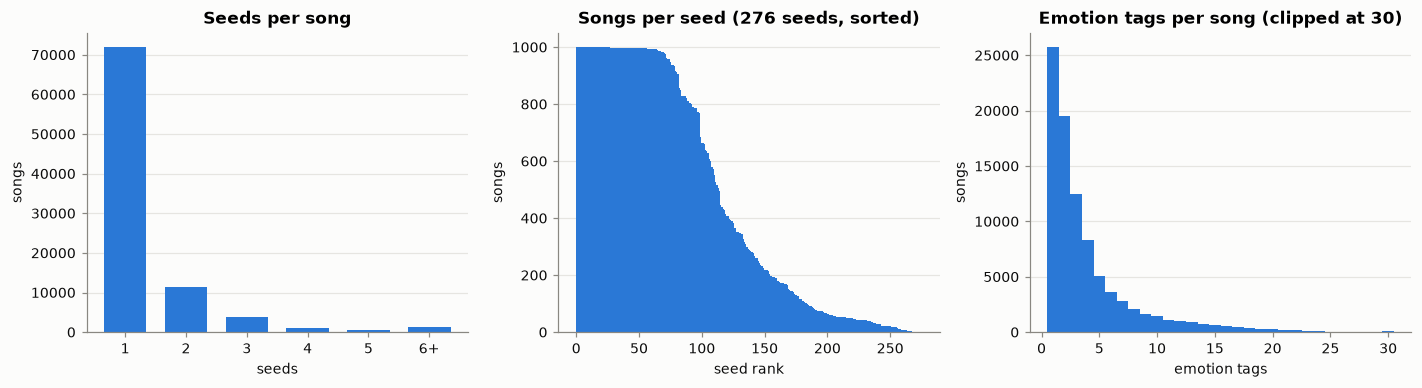

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

per_song = muse["n_seeds"].clip(upper=6).value_counts().sort_index()
axes[0].bar([str(i) if i < 6 else "6+" for i in per_song.index], per_song.values, color=BLUE, width=0.7)
axes[0].set_title("Seeds per song")
axes[0].set_xlabel("seeds")
axes[0].set_ylabel("songs")
axes[0].grid(axis="x", visible=False)

axes[1].bar(range(len(seed_counts)), seed_counts.values, color=BLUE, width=1.0)
axes[1].set_title(f"Songs per seed ({len(seed_counts)} seeds, sorted)")
axes[1].set_xlabel("seed rank")
axes[1].set_ylabel("songs")
axes[1].grid(axis="x", visible=False)

axes[2].hist(muse["number_of_emotion_tags"].clip(upper=30), bins=np.arange(0.5, 31.5), color=BLUE)
axes[2].set_title("Emotion tags per song (clipped at 30)")
axes[2].set_xlabel("emotion tags")
axes[2].set_ylabel("songs")
axes[2].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

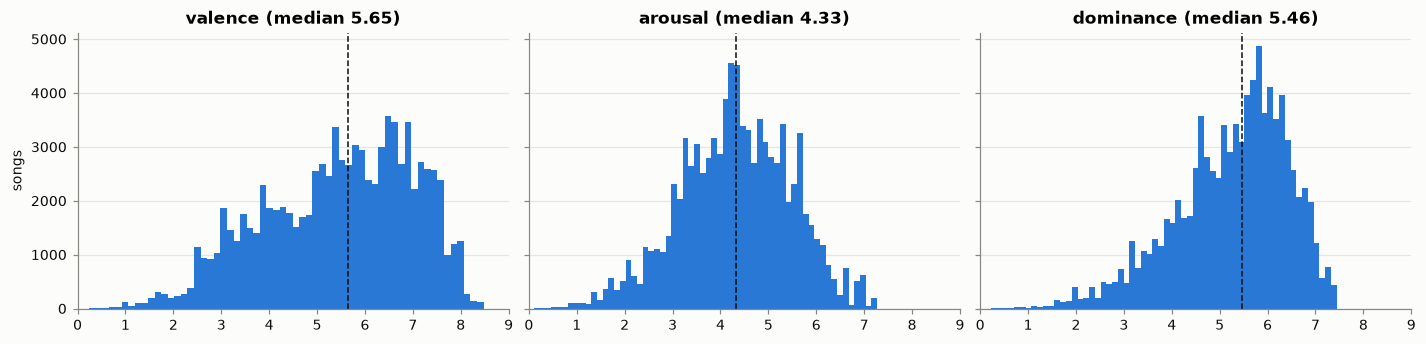

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, col in zip(axes, VAD):
    ax.hist(muse[col], bins=60, color=BLUE)
    ax.axvline(muse[col].median(), color=INK, lw=1, ls="--")
    ax.set_title(f"{col.split('_')[0]} (median {muse[col].median():.2f})")
    ax.set_xlim(0, 9)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("songs")
plt.tight_layout()
plt.show()

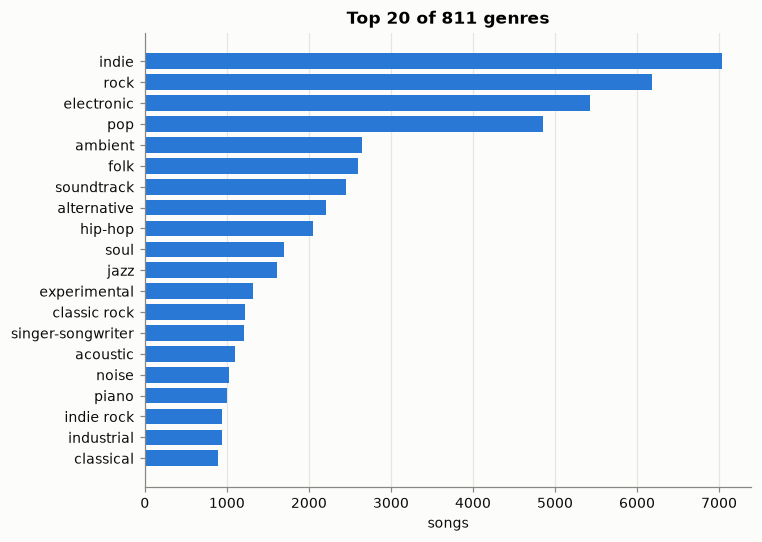

top 20 genres cover 58% of songs with a genre; genres with < 10 songs: 492


In [19]:
top_genres = muse["genre"].value_counts().head(20).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_genres.index, top_genres.values, color=BLUE, height=0.75)
ax.set_title(f"Top 20 of {muse['genre'].nunique()} genres")
ax.set_xlabel("songs")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
print(f"top 20 genres cover {top_genres.sum() / muse['genre'].notna().sum():.0%} of songs with a genre; "
      f"genres with < 10 songs: {(muse['genre'].value_counts() < 10).sum()}")

**Response.**

**Seeds per song.** 80% of songs (71,934) were found by a single seed and 12.7% by two. Most songs therefore have one weak label, which fits the "this dimension is high" training setup.

**Songs per seed.**
- 66 seeds are at or near the 1,000-song cap (≥ 990 songs), then the counts fall off in a long tail.
- How balanced our dimensions are will depend on which seeds we group together, not on the raw seeds.

**Emotion tags per song.**
- Median 2. 29% of songs have only one emotion tag, and 90% have 9 or fewer.
- Most songs are thinly described *within the lexicon*. The count also works as a rough popularity measure: the lyrics section uses it to show that well-tagged songs more often have lyrics.

**Valence / arousal / dominance.**
- Valence has the widest spread (median 5.65, sd 1.55) and leans positive.
- Arousal sits below the scale midpoint (median 4.33). This doesn't mean the catalogue is calm: the lexicon's own words average about 4.2 on arousal (Warriner et al., 2013), so low scores are largely a property of the lexicon.
- Dominance (median 5.46) has almost the same shape as valence.
- The spikes in all three come from the shared points described in Q5.

**Genre.**
- 811 values, but the top 20 cover 58% of songs that have a genre, and 492 genres have fewer than 10 songs.
- Indie (7,041), rock (6,179), electronic (5,432) and pop (4,854) dominate, which reflects Last.fm's mostly Western, indie-leaning userbase.
- We report this as a limitation.

### 7. Perform bi-variate analysis on some of the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables.

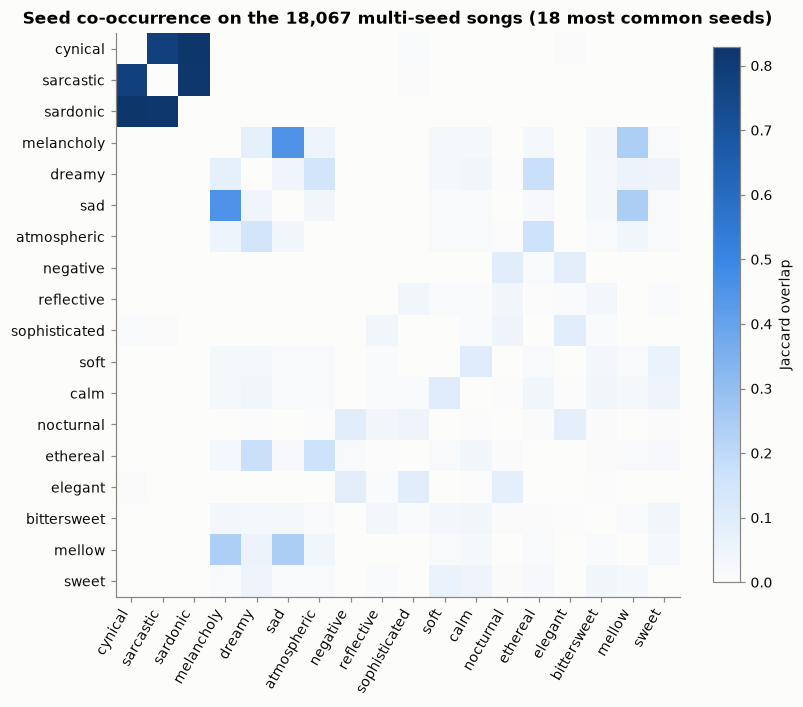

strongest pairs: {'cynical + sardonic': 0.83, 'sarcastic + sardonic': 0.82, 'cynical + sarcastic': 0.78, 'melancholy + sad': 0.45, 'sad + mellow': 0.24, 'melancholy + mellow': 0.24, 'dreamy + ethereal': 0.17, 'atmospheric + ethereal': 0.16}


In [23]:
# Seed x seed: which seeds are found on the same songs?
multi = muse[muse["n_seeds"] > 1]
top = multi.explode("seeds")["seeds"].value_counts().head(18).index
onehot = pd.DataFrame({s: multi["seeds"].apply(lambda xs, s=s: s in xs) for s in top}).astype(int)
co = onehot.T @ onehot
jaccard = co / (np.add.outer(np.diag(co), np.diag(co)) - co)
jaccard = jaccard.mask(np.eye(len(top), dtype=bool))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(jaccard, cmap=BLUES)
ax.set_xticks(range(len(top)), top, rotation=60, ha="right")
ax.set_yticks(range(len(top)), top)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Jaccard overlap", fraction=0.04)
ax.set_title(f"Seed co-occurrence on the {len(multi):,} multi-seed songs (18 most common seeds)")
plt.tight_layout()
plt.show()
pairs = jaccard.where(np.triu(np.ones(jaccard.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
print("strongest pairs:", {f"{a} + {b}": round(v, 2) for (a, b), v in pairs.head(8).items()})

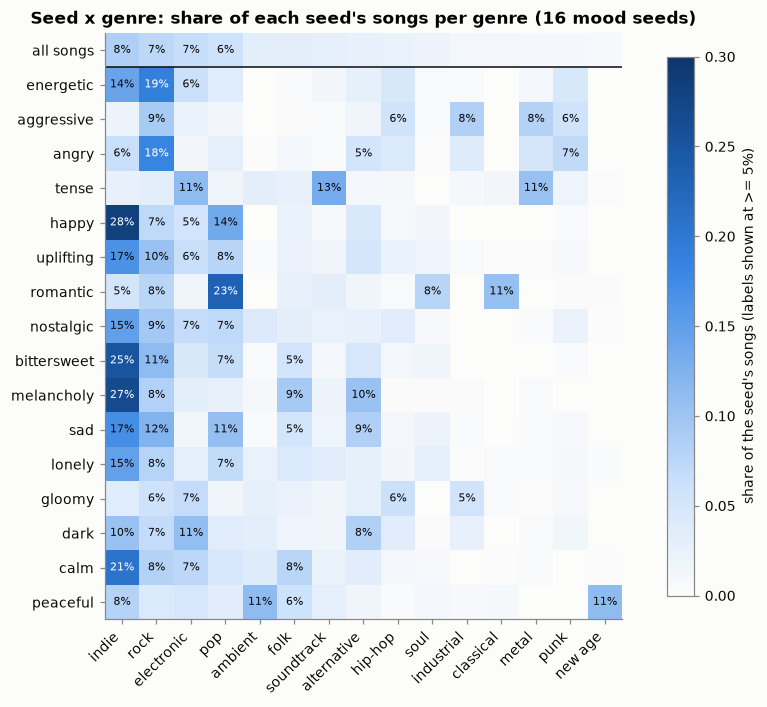

share of songs in these genres: {'energetic': 0.59, 'aggressive': 0.45, 'angry': 0.56, 'tense': 0.54, 'happy': 0.65, 'uplifting': 0.56, 'romantic': 0.64, 'nostalgic': 0.57, 'bittersweet': 0.62, 'melancholy': 0.65, 'sad': 0.62, 'lonely': 0.52, 'gloomy': 0.41, 'dark': 0.55, 'calm': 0.61, 'peaceful': 0.57} | all songs: 0.49


In [40]:
# Seed x genre: is a mood word tied to one kind of music?
KEY_SEEDS = ["energetic", "aggressive", "angry", "tense", "happy", "uplifting", "romantic", "nostalgic",
             "bittersweet", "melancholy", "sad", "lonely", "gloomy", "dark", "calm", "peaceful"]
key = seeds_long[seeds_long["seed"].isin(KEY_SEEDS) & seeds_long["genre"].notna()]
share = key.groupby("seed")["genre"].value_counts(normalize=True).unstack(fill_value=0).loc[KEY_SEEDS]
overall = muse["genre"].value_counts(normalize=True)
# Columns: each seed's top 3 genres, ordered by how common the genre is in the whole catalogue.
cols = overall.index[overall.index.isin(share.apply(lambda r: r.nlargest(3).index.tolist(), axis=1).explode())]
grid = pd.concat([overall[cols].to_frame("all songs").T, share[cols]])

fig, ax = plt.subplots(figsize=(9, 6.5))
im = ax.imshow(grid, cmap=BLUES, vmin=0, vmax=0.3)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(grid)), grid.index)
ax.axhline(0.5, color=INK, lw=1)
ax.grid(False)
for i in range(len(grid)):
    for j in range(len(cols)):
        if grid.iloc[i, j] >= 0.05:
            ax.text(j, i, f"{grid.iloc[i, j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if grid.iloc[i, j] > 0.18 else INK)
fig.colorbar(im, ax=ax, label="share of the seed's songs (labels shown at >= 5%)", fraction=0.03)
ax.set_title(f"Seed x genre: share of each seed's songs per genre ({len(KEY_SEEDS)} mood seeds)")
plt.tight_layout()
plt.show()
print("share of songs in these genres:", share[cols].sum(axis=1).round(2).to_dict(),
      "| all songs:", round(overall[cols].sum(), 2))

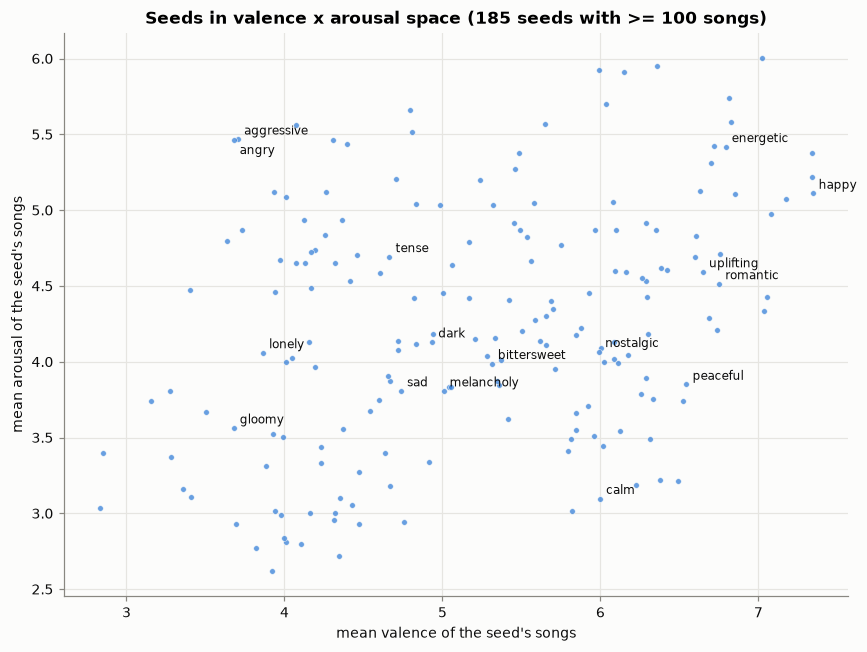

lowest valence: {'macabre': 2.83, 'sardonic': 2.85, 'cynical': 3.15, 'sarcastic': 3.27, 'fractured': 3.28}
highest valence: {'happy': 7.34, 'cheerful': 7.34, 'fun': 7.34, 'humorous': 7.17, 'positive': 7.08}
highest arousal: {'exciting': 6.0, 'sexual': 5.95, 'erotic': 5.92, 'spicy': 5.91, 'exotic': 5.74}


In [41]:
# Seed x valence/arousal: does each seed word sit where its meaning says it should?
by_seed = seeds_long.groupby("seed").agg(valence=("valence_tags", "mean"), arousal=("arousal_tags", "mean"),
                                         songs=("seed", "size"))
by_seed = by_seed[by_seed["songs"] >= 100]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(by_seed["valence"], by_seed["arousal"], s=14, color=BLUE, alpha=0.7, edgecolor="#fcfcfb", lw=0.5)
for s in KEY_SEEDS:
    if s in by_seed.index:
        ax.annotate(s, by_seed.loc[s, ["valence", "arousal"]], xytext=(4, -9) if s == "angry" else (4, 3), textcoords="offset points",
                    fontsize=8, color=INK)
ax.set_xlabel("mean valence of the seed's songs")
ax.set_ylabel("mean arousal of the seed's songs")
ax.set_title(f"Seeds in valence x arousal space ({len(by_seed)} seeds with >= 100 songs)")
plt.tight_layout()
plt.show()
print("lowest valence:", by_seed["valence"].nsmallest(5).round(2).to_dict())
print("highest valence:", by_seed["valence"].nlargest(5).round(2).to_dict())
print("highest arousal:", by_seed["arousal"].nlargest(5).round(2).to_dict())

**Response.**

**1. Seed × seed co-occurrence (Jaccard overlap on the 18,067 multi-seed songs).**
- *cynical / sarcastic / sardonic* overlap 0.78–0.83, so they find almost the same songs and form one group.
- *sad + melancholy* overlap 0.45. *mellow* overlaps 0.24 with both, and *ethereal / dreamy / atmospheric* overlap about 0.16.
- Single-seed songs are left out, so these overlaps are higher than they would be across all songs. Read them as relative, not absolute.
- These overlaps come from the data, and they back up the synonym groups we draw up by hand in Stage 1. Most other pairs barely overlap, so most seeds are distinct.

**2. Seed × genre (share of each seed's songs per genre, 16 mood seeds).**
- **No seed belongs to one genre.** Even the most concentrated, *happy*, has only 28% of its songs in its top genre (indie). Every seed spreads across many genres.
- **But each seed leans towards some genres**, compared with the catalogue as a whole (top row):
  - *happy, bittersweet, melancholy* and *calm* lean indie (21–28% vs 8% overall)
  - *romantic* leans pop (23% vs 6%), plus soul and classical
  - *energetic* and *angry* lean rock (18–19% vs 7%). *aggressive* spreads over industrial, metal and punk
  - *tense* leans soundtrack (13%) and metal (11%). *peaceful* leans ambient and new age (11% each)
- **Why it matters:**
  - The song model could pick up genre vocabulary instead of mood. Splitting by artist doesn't stop this, since a genre spans many artists. Results per dimension will show whether a dimension only tracks a genre.
  - Lyrics coverage depends on genre (ambient 4%, electronic 44%, see the lyrics section). So genre-leaning seeds such as *peaceful* and *tense* will lose more songs than *happy* or *sad*.
- Genre labels are messy (*hip-hop* and *hip hop* are separate values, 7% missing), so these shares are approximate.

**3. Seed × valence/arousal (one dot per seed with ≥ 100 songs).**
- The seeds sit where their meaning says they should. *happy, cheerful, fun* have the highest valence (≈ 7.3) and *macabre, sardonic, cynical* the lowest. *aggressive* and *angry* are high arousal, low valence. *calm* and *peaceful* are low arousal, positive valence.
- **This is partly circular.** Each seed is itself one of the song's tags, so it feeds into the song's score. The plot shows that the seeds and the lexicon agree (a sanity check), not that the seeds describe the music.

### 8. Provide relevant summary statistics for the features you're planning to use. Briefly explain why you may or may not use certain variables.

In [24]:
# Dominance is dropped below: it nearly duplicates valence
print(f"valence-dominance r = {muse['valence_tags'].corr(muse['dominance_tags']):.2f}")
display(muse[VAD + ["number_of_emotion_tags", "n_seeds"]].describe(percentiles=[.25, .5, .75, .99]).round(2))
display(seed_counts.describe().round(1).to_frame("songs per seed").T)
muse[["artist", "genre"]].describe()

,valence_tags,arousal_tags,dominance_tags,number_of_emotion_tags,n_seeds
count,90001.00,90001.00,90001.00,90001.00,90001.00
mean,5.45,4.32,5.25,3.99,1.39
std,1.55,1.15,1.17,4.15,1.36
min,0.24,0.11,0.23,1.00,1.00
25%,4.28,3.53,4.55,1.00,1.00
50%,5.65,4.33,5.46,2.00,1.00
75%,6.70,5.15,6.12,5.00,1.00
99%,8.00,6.90,7.21,20.00,6.00
max,8.48,7.27,7.44,50.00,44.00


,count,mean,std,min,25%,50%,75%,max
songs per seed,276.0,453.5,406.9,1.0,54.8,289.5,983.0,1000.0


,artist,genre
count,90001,83362
unique,26012,811
top,志方あきこ,indie
freq,302,7041


**Response.**

The summary tables above give the numeric features, songs per seed, and the artist and genre counts.

| Decision | Feature | Why |
|---|---|---|
| **Use** | `seeds` | Weak label: each seed maps to a mood dimension in Stage 1. A seed word can also appear in the lyrics (*"lonely"*), so we train with seed words masked and unmasked, and compare |
| **Use** | `artist`, `track` | To look up each song's lyrics on LRCLIB, the song model's input. `artist` is also used to split train and test by artist |
| **Use** | `lastfm_url` | Unique key |
| **Use** | `spotify_id` | For de-duplication (Q5) and playback. Not a model input |
| **Use** | `number_of_emotion_tags`, `n_seeds` | To flag thinly-tagged songs and down-weight songs with many seeds |
| **Describe only** | `genre` | To report the catalogue's bias. Not a model input, so the model stays about mood rather than genre |
| **Sanity check only** | `valence_tags`, `arousal_tags` | Word scores of the tags, not ratings of the music, so at most a rough check. Used in the lyrics section to slice songs by quadrant |
| **Drop** | `dominance_tags` | r = 0.86 with valence, so it adds almost nothing |
| **Drop** | `mbid` | A second ID. We match on Spotify ID or artist + title |

## Last.fm tags: sample fetch (failed)

We first tried to fetch each song's full Last.fm tags (`track.getTopTags`) as the song model's input. **It failed: 500 of 506 sampled songs came back with no tags.** Last.fm now returns tags only for very popular songs. The code and results moved to [FAILED_edas.ipynb](FAILED_edas.ipynb). The song model reads lyrics instead (next section).

## Dataset for Song Encoding: MuSe lyrics (LRCLIB)

MuSe has no text for each song beyond its seed word(s), and Last.fm no longer returns track tags (previous section). So the song model reads each song's **lyrics**, labelled with the song's MuSe seed(s).

**Source.** [LRCLIB](https://lrclib.net) is a free, open lyrics database with a public API and no key. We search it by MuSe's `artist` and `track`.

**Sample.** Fetched 1000 random songs that are in MuSe. Fetch the rest in Milestone 2.

**Copyright.** Lyrics are copyrighted and this repository is public so no cell prints lyrics text. The lyrics are cached locally in `data/` (git-ignored).

#### Fetching

For each song we fetch with the artist and title. LRCLIB returns a list of candidate songs. We accept a candidate only if its artist **and** title match MuSe's after normalising both: lower-case, accents removed, and bracketed or ` - ` suffixes dropped (*"Creep (Acoustic) - Remastered"* becomes *"creep"*).

A wrong song's lyrics are worse than none, so a song with no exact match counts as having no lyrics.

LRCLIB often answers `HTTP 503` (busy), so each call retries with backoff. Every result is cached to `data/raw/lrclib/sample_1000.jsonl`: re-running makes no API calls, and an interrupted fetch picks up where it stopped. The cache keeps every candidate's name, but the lyrics of the matched candidate only.

In [29]:
import json
import time
import unicodedata
import urllib.parse
import urllib.request
from urllib.error import HTTPError, URLError

INTERIM = Path("../data/interim")
LRCLIB_CACHE = DATA / "lrclib" / "sample_1000.jsonl"
N_SAMPLE = 1000

sample = muse.sample(N_SAMPLE, random_state=42)


def norm(name):
    """Comparable form of an artist or title: "Creep (Acoustic) - Remastered" -> "creep"."""
    name = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode().lower()
    name = re.sub(r"\(.*?\)|\[.*?\]| - .*$", "", name)
    return re.sub(r"[^a-z0-9]+", " ", name).strip()


def search_lrclib(artist, track, retries=5):
    """One /api/search call. Returns the list of candidates, or {"error": ...} after retries."""
    query = urllib.parse.urlencode({"artist_name": artist, "track_name": track})
    request = urllib.request.Request(f"https://lrclib.net/api/search?{query}",
                                     headers={"User-Agent": "MoodMix-student-project/0.1"})
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(request, timeout=30) as r:
                return json.load(r)
        except HTTPError as e:  # 503 = busy, 429 = rate limited: wait and retry
            error = {"error": e.code}
            if e.code < 500 and e.code != 429:
                return error
        except (URLError, TimeoutError, ValueError) as e:
            error = {"error": -1, "message": str(e)}
        time.sleep(2 ** attempt)
    return error


def to_record(row, response):
    """Cache record: every candidate's name, and the lyrics of the exact match only."""
    if isinstance(response, dict):
        return {"lastfm_url": row.lastfm_url, **response}
    meta = ["id", "trackName", "artistName", "albumName", "duration", "instrumental"]
    candidates = [{k: c.get(k) for k in meta} for c in response]
    match = next((c for c in response
                  if norm(c.get("artistName") or "") == norm(row.artist)
                  and norm(c.get("trackName") or "") == norm(row.track)), None)
    return {"lastfm_url": row.lastfm_url, "candidates": candidates,
            "match_id": match["id"] if match else None,
            "plain_lyrics": match.get("plainLyrics") if match else None}

In [26]:
# Fetch every sampled song not already cached (about 1 song per second; failed calls are retried on re-run).
LRCLIB_CACHE.parent.mkdir(parents=True, exist_ok=True)
done = set()
if LRCLIB_CACHE.exists():
    with LRCLIB_CACHE.open(encoding="utf-8") as f:
        done = {r["lastfm_url"] for r in map(json.loads, f) if "error" not in r}

todo = sample[~sample["lastfm_url"].isin(done)]
with LRCLIB_CACHE.open("a", encoding="utf-8") as f:
    for i, row in enumerate(todo.itertuples(), 1):
        started = time.monotonic()
        f.write(json.dumps(to_record(row, search_lrclib(row.artist, row.track)), ensure_ascii=False) + "\n")
        f.flush()
        if i % 100 == 0:
            print(f"{i}/{len(todo)} fetched")
        time.sleep(max(0, 1.0 - (time.monotonic() - started)))
print(f"cache: {len(done) + len(todo):,} songs ({len(todo):,} fetched now)")

cache: 1,000 songs (0 fetched now)


#### Tidy table

One row per sampled song in `lyr`. Each song gets a `status`:
- `lyrics`: an exact match with lyrics
- `instrumental`: an exact match that LRCLIB marks as instrumental, or that has no lyrics text
- `name_mismatch`: LRCLIB returned candidates, but none matched both artist and title
- `no_hit`: LRCLIB returned no candidates
- `error`: the call still failed after retries (re-run the fetch cell to retry these)

Lyrics aren't tabular, so the features below are engineered from the text (as the template asks for non-tabular data). The lyrics text stays in the `lyrics` column and is never displayed.

In [27]:
from langdetect import DetectorFactory, LangDetectException, detect

DetectorFactory.seed = 0  # langdetect is random by default; fix it so results repeat
WORDS_PER_TOKEN = 1 / 1.3  # rough: MiniLM's tokenizer makes ~1.3 word pieces per English word
TOKEN_LIMIT = 256          # all-MiniLM-L6-v2 truncates its input here

with LRCLIB_CACHE.open(encoding="utf-8") as f:
    records = {r["lastfm_url"]: r for r in map(json.loads, f)}  # a retried song keeps its last record


def status_of(r):
    if "error" in r:
        return "error"
    if not r["candidates"]:
        return "no_hit"
    if r["match_id"] is None:
        return "name_mismatch"
    matched = next(c for c in r["candidates"] if c["id"] == r["match_id"])
    return "instrumental" if matched["instrumental"] or not (r["plain_lyrics"] or "").strip() else "lyrics"


def language(text):
    try:
        return detect(text)
    except LangDetectException:  # no letters to go on
        return "unknown"


rows = []
for song in sample.itertuples():
    r = records.get(song.lastfm_url, {"error": "not fetched"})
    status = status_of(r)
    matched = next((c for c in r.get("candidates", []) if c["id"] == r.get("match_id")), {})
    text = (r.get("plain_lyrics") or "") if status == "lyrics" else ""
    lines_ = [l.strip() for l in text.splitlines() if l.strip()]
    rows.append({
        "lastfm_url": song.lastfm_url, "status": status, "n_candidates": len(r.get("candidates", [])),
        "lrclib_id": r.get("match_id"), "lrclib_artist": matched.get("artistName"),
        "lrclib_track": matched.get("trackName"), "lrclib_album": matched.get("albumName"),
        "lyrics": text or None,
        "n_words": len(re.findall(r"[^\W\d_]+(?:'[^\W\d_]+)?", text)) if text else np.nan,
        "n_lines": len(lines_) if text else np.nan,
        "n_stanzas": len([b for b in re.split(r"\n\s*\n", text) if b.strip()]) if text else np.nan,
        "repeat_share": 1 - len(set(map(str.lower, lines_))) / len(lines_) if lines_ else np.nan,
        "language": language(text) if text else None,
    })

lyr = sample[["lastfm_url", "artist", "track", "seeds", "genre", "valence_tags", "arousal_tags",
              "number_of_emotion_tags"]].merge(pd.DataFrame(rows), on="lastfm_url")
lyr["est_tokens"] = lyr["n_words"] / WORDS_PER_TOKEN
lyr["quadrant"] = (np.where(lyr["valence_tags"] >= 5, "positive", "negative") + " / "
                   + np.where(lyr["arousal_tags"] >= 5, "high energy", "low energy"))
has = lyr[lyr["status"] == "lyrics"]
lyr.drop(columns="lyrics").head()

,lastfm_url,artist,track,seeds,genre,valence_tags,arousal_tags,number_of_emotion_tags,status,n_candidates,lrclib_id,lrclib_artist,lrclib_track,lrclib_album,n_words,n_lines,n_stanzas,repeat_share,language,est_tokens,quadrant
0,https://www.last.fm/music/blackstreet/_/falling%2bin%2blove%2bagain,Blackstreet,Falling In Love Again,[sexual],hip hop,7.353333,6.370000,3,lyrics,13,34097558.0,Blackstreet,Falling In Love Again,No Diggity: Very Best of Blackstreet (Compilation),369.0,45.0,7.0,0.133333,en,479.7,positive / high energy
1,https://www.last.fm/music/lucifers%2bcrossing/_/blasphemer,Lucifers Crossing,Blasphemer,[macabre],metal,3.172857,4.494286,6,no_hit,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,negative / low energy
2,https://www.last.fm/music/madonna/_/justify%2bmy%2blove%2b%2528porno%2bmix%2529%2brare,Madonna,Justify My Love (porno mix) Rare,[sexual],NaN,6.640000,6.950000,1,no_hit,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,positive / high energy
3,https://www.last.fm/music/aimee%2bmann/_/one,Aimee Mann,One,"[melancholy, sad]",soundtrack,4.683675,3.500171,19,lyrics,20,37066484.0,Aimee Mann,One,Cinematic Treatment,157.0,33.0,8.0,0.333333,en,204.1,negative / low energy
4,https://www.last.fm/music/linkin%2bpark/_/roads%2buntraveled,Linkin Park,Roads Untraveled,[sad],alternative rock,3.652632,3.982105,2,lyrics,20,34478269.0,Linkin Park,Roads Untraveled,Linkin Park Videos,86.0,12.0,3.0,0.083333,en,111.8,negative / low energy


### 1. Summarise the background of the dataset(s) which you're using, and how they contribute to your project [limited to 100 words per dataset]

**Response.**

[LRCLIB](https://lrclib.net) is a free, community-built lyrics database with an open API. We search it by each MuSe song's artist and title. MuSe gives each song a mood label (its seed) but no text, so lyrics become the song model's input: the model learns to read a song's mood from its words, with the MuSe seed as the label. This section checks how many MuSe songs have lyrics on LRCLIB, what the lyrics look like (length, language), and whether they are usable with our encoder.

### 2. State the size of your dataset(s)

In [28]:
status_counts = lyr["status"].value_counts().reindex(
    ["lyrics", "instrumental", "name_mismatch", "no_hit", "error"], fill_value=0)
display(pd.DataFrame({"songs": status_counts, "%": (status_counts / len(lyr) * 100).round(1)}).T)
print(f"{len(lyr):,} songs looked up; {len(has):,} with lyrics; "
      f"{int(has['n_words'].sum()):,} words of lyrics in total")

status,lyrics,instrumental,name_mismatch,no_hit,error
songs,591.0,35.0,10.0,364.0,0.0
%,59.1,3.5,1.0,36.4,0.0


1,000 songs looked up; 591 with lyrics; 145,342 words of lyrics in total


**Response.**

- **1,000 songs looked up** (random sample of MuSe, the same songs as the failed Last.fm attempt).
- **591 (59.1%) have lyrics**, 145,342 words in total. 35 (3.5%) are instrumental. 10 (1.0%) had candidates whose names didn't match. 364 (36.4%) returned nothing. No call failed after retries.
- **543 (54%) have English lyrics**, which is what the song model can use (see Q5).
- For comparison, on the same songs Last.fm returned tags for only 6 of 506.
- Scaled to the whole catalogue, ~54% of 90,001 songs is **~49,000 usable songs**, well above the few thousand the head needs.

### 3. For each feature of your dataset, describe what it represents and its data type (numerical, categorical, unstructured string, etc)

In [29]:
display(lyr.drop(columns="lyrics").dtypes.rename("dtype").to_frame().T)
lyr[["n_candidates", "n_words", "n_lines", "n_stanzas", "repeat_share", "est_tokens"]].agg(["min", "max"]).round(2)

,lastfm_url,artist,track,seeds,genre,valence_tags,arousal_tags,number_of_emotion_tags,status,n_candidates,lrclib_id,lrclib_artist,lrclib_track,lrclib_album,n_words,n_lines,n_stanzas,repeat_share,language,est_tokens,quadrant
dtype,str,str,str,object,str,float64,float64,int64,str,int64,float64,str,str,str,float64,float64,float64,float64,str,float64,str


,n_candidates,n_words,n_lines,n_stanzas,repeat_share,est_tokens
min,0,8.0,1.0,1.0,0.00,10.4
max,20,1043.0,121.0,35.0,0.92,1355.9


**Response.**

| Feature | What it represents | Data type |
|---|---|---|
| `lastfm_url`, `artist`, `track`, `seeds`, `genre`, `valence_tags`, `arousal_tags`, `number_of_emotion_tags` | Carried over from MuSe (see the MuSe section) | as in MuSe |
| `status` | Lookup result: `lyrics`, `instrumental`, `name_mismatch`, `no_hit`, `error` | categorical |
| `n_candidates` | How many songs LRCLIB's search returned (capped at 20) | numerical (int) |
| `lrclib_id` | LRCLIB's ID of the matched song | ID (stored as float because of NaNs) |
| `lrclib_artist`, `lrclib_track`, `lrclib_album` | Names of the matched song on LRCLIB | string |
| `lyrics` | The lyrics text. **Never displayed** (copyright) | unstructured string |
| `n_words` | Words in the lyrics | numerical (int, NaN without lyrics) |
| `n_lines` | Non-empty lines | numerical |
| `n_stanzas` | Blocks separated by blank lines | numerical |
| `repeat_share` | Share of lines that repeat another line (choruses, refrains): 1 − unique lines ÷ lines | numerical (0–1) |
| `language` | Language detected by `langdetect` | categorical (ISO code) |
| `est_tokens` | Estimated word pieces for the encoder: words × 1.3 | numerical |
| `quadrant` | MuSe's lexicon valence × arousal quadrant, split at 5. For slicing the EDA only, not a label | categorical |

### 4. For each feature, determine percentage of missing data. Describe how you're planning on resolving the missing data. State any assumptions you make

In [30]:
missing = (lyr.drop(columns="lyrics").isna().mean() * 100).round(1).to_frame("% missing")
display(missing.T)

# Is "no lyrics" random? Coverage by popularity proxy (number of emotion tags) and by genre.
lyr["found"] = lyr["status"] == "lyrics"
tag_bins = pd.cut(lyr["number_of_emotion_tags"], [0, 1, 3, 7, 15, 1000], labels=["1", "2-3", "4-7", "8-15", "16+"])
display((lyr.groupby(tag_bins, observed=True)["found"].agg(["size", "mean"])
         .rename(columns={"size": "songs", "mean": "share with lyrics"}).round(2).T))
top_genres = lyr["genre"].value_counts().head(10).index
display((lyr[lyr["genre"].isin(top_genres)].groupby("genre")["found"].agg(["size", "mean"])
         .rename(columns={"size": "songs", "mean": "share with lyrics"}).sort_values("share with lyrics")
         .round(2).T))
display((lyr.groupby("quadrant")["found"].agg(["size", "mean"])
         .rename(columns={"size": "songs", "mean": "share with lyrics"}).round(2).T))

,lastfm_url,artist,track,seeds,genre,valence_tags,arousal_tags,number_of_emotion_tags,status,n_candidates,lrclib_id,lrclib_artist,lrclib_track,lrclib_album,n_words,n_lines,n_stanzas,repeat_share,language,est_tokens,quadrant
% missing,0.0,0.0,0.0,0.0,8.7,0.0,0.0,0.0,0.0,0.0,37.4,37.4,37.4,37.4,40.9,40.9,40.9,40.9,40.9,40.9,0.0


number_of_emotion_tags,1,2-3,4-7,8-15,16+
songs,294.0,358.00,217.00,108.00,23.00
share with lyrics,0.5,0.56,0.65,0.78,0.78


genre,ambient,jazz,electronic,folk,hip-hop,indie,alternative,soul,rock,pop
songs,23.00,21.00,62.00,28.00,30.00,75.00,25.0,20.00,60.00,68.00
share with lyrics,0.04,0.38,0.44,0.64,0.67,0.77,0.8,0.85,0.87,0.88


quadrant,negative / high energy,negative / low energy,positive / high energy,positive / low energy
songs,70.00,293.00,220.00,417.0
share with lyrics,0.53,0.56,0.63,0.6


**Response.**

| Feature | % missing | Why | Plan |
|---|---|---|---|
| `lrclib_id`, `lrclib_*` names | 37.4% | No exact match (no hit or name mismatch) | Expected. The song has no lyrics |
| `lyrics` and every text feature | 40.9% | The above, plus 35 instrumental songs | **Drop these songs from the song model's catalogue.** They have no input text |
| `genre` | 8.7% | Missing in MuSe | As in the MuSe section |

**Is "no lyrics" random? No.**
- **Popularity.** Songs with more emotion tags on Last.fm (a rough popularity measure) have lyrics more often: 50% with 1 tag, 56% with 2–3, 65% with 4–7, 78% with 8 or more. Obscure songs drop out first.
- **Genre.** Ambient (4%), jazz (38%) and electronic (44%) are mostly missing, often because they're instrumental. Pop (88%), rock (87%) and soul (85%) are almost complete.
- **Mood.** Smaller differences across valence × arousal quadrants: 53% (negative / high energy) to 63% (positive / high energy).

**Assumption and consequence.** We treat a song without lyrics as unusable, not as "no mood". The catalogue therefore leans further towards popular, vocal, pop/rock songs, and ambient and electronic moods (*calm*, *dreamy*) will have fewer training songs. We state this as a limitation and check per-mood song counts once the dimensions are fixed.

### 5. For each feature, identify outliers or mismatched data. Describe how you plan to handle them. Clearly state any assumption you made.

#### Hand-check: are the matches the right songs?

Matching on artist + title can still pick the **wrong song**: a cover filed under the same artist name, two different songs with the same title, or a live or remixed version whose lyrics differ. A wrong match is worse than a missing one: the model would learn from another song's words. We want a measured error rate, and only a person can judge a match.

**How.** The cell below writes 50 random matched songs to `data/interim/lyrics_match_check.csv`. For each one it gives MuSe's artist and title, LRCLIB's artist, title and album, and the first 2 lines of the lyrics. A person fills the `correct` column with `y` or `n`, then re-runs the cell to get the error rate.

**Why a separate file.** Lyrics are copyrighted and this notebook is public, so the lyric lines go into a git-ignored file under `data/` and never into a cell output. The notebook only reads back the `y`/`n` verdicts.

In [34]:
CHECK = INTERIM / "lyrics_match_check.csv"
if not CHECK.exists():
    picks = has.sample(min(50, len(has)), random_state=0)
    first_lines = picks["lyrics"].map(lambda t: " / ".join([l for l in t.splitlines() if l.strip()][:2]))
    (picks[["lastfm_url", "artist", "track", "lrclib_artist", "lrclib_track", "lrclib_album"]]
     .assign(first_two_lines=first_lines, correct="").to_csv(CHECK, index=False))
    print(f"wrote {CHECK}: fill the 'correct' column with y/n, then re-run this cell")
else:
    verdicts = pd.read_csv(CHECK)["correct"].astype(str).str.strip().str.lower()
    judged = verdicts[verdicts.isin(["y", "n"])]
    print(f"{len(judged)}/{len(verdicts)} judged; wrong matches: {(judged == 'n').sum()} "
          f"({(judged == 'n').mean():.0%})" if len(judged) else "no verdicts yet")

50/50 judged; wrong matches: 0 (0%)


In [32]:
# Other suspect rows
placeholder = has["lyrics"].str.contains(r"instrumental|lyrics not available|no lyrics", case=False) & (has["n_words"] < 30)
dupe_text = has[has.duplicated("lyrics", keep=False)]
print(f"placeholder text instead of lyrics: {placeholder.sum()}")
print(f"songs sharing identical lyrics with another song: {len(dupe_text)} "
      f"({dupe_text['lyrics'].nunique()} distinct texts)")
if len(dupe_text):
    display(dupe_text.sort_values("lyrics")[["artist", "track", "lrclib_artist", "lrclib_track"]])
print(f"very short (< 30 words): {(has['n_words'] < 30).sum()}; "
      f"very long (> 800 words): {(has['n_words'] > 800).sum()}")
display(has.loc[has["n_words"] < 30, ["artist", "track", "n_words", "language"]])
no_breaks = has["n_stanzas"] == 1
print(f"no stanza breaks (one block): {no_breaks.sum()} ({no_breaks.mean():.0%}); "
      f"of these over the {TOKEN_LIMIT}-token limit: {(no_breaks & (has['est_tokens'] > TOKEN_LIMIT)).sum()}")
lang = has["language"].value_counts()
print(f"non-English: {(has['language'] != 'en').sum()} of {len(has)} ({(has['language'] != 'en').mean():.0%})")

placeholder text instead of lyrics: 0
songs sharing identical lyrics with another song: 0 (0 distinct texts)
very short (< 30 words): 2; very long (> 800 words): 6


,artist,track,n_words,language
576,Agonoize,sexual violation,20.0,en
876,Swan Lake,The Pollenated Girls,8.0,en


no stanza breaks (one block): 81 (14%); of these over the 256-token limit: 30
non-English: 48 of 591 (8%)


**Response.**

**1. Wrong matches (hand-check).** We checked 50 random matched songs by hand (`data/interim/lyrics_match_check.csv`): **all 50 were the right song**, so 0 wrong matches. With 50 checks, that means the true error rate is most likely under ~6% (rule of three: 3 ÷ 50). Exact artist + title matching is reliable enough, so we keep it for the full fetch.

**2. Near-miss name mismatches.** The 10 `name_mismatch` songs are mostly the *right* song under a slightly different name: *Misfits* vs *The Misfits*, "feat. X" written differently, a curly vs straight apostrophe (*L’amour*), *[:SITD:]* vs *SITD*, and classical pieces with long work titles. At 1% this costs little. For the full fetch we can also normalise a leading "The", "feat." parts and apostrophes.

**3. Non-English lyrics.** Of the 591 songs with lyrics, 48 (8%) are not English: Italian, French, German and Japanese lead, with 6–9 songs each. `all-MiniLM-L6-v2` is English-only, so **we drop them**: the catalogue is English songs with lyrics.

**4. Very short and very long lyrics.** 2 songs have under 30 words (an indie song with 8 words and an EBM track with 20). They're real but give the model little to read, so we keep them and flag them. 6 songs have over 800 words (5 rap / hip-hop, 1 rock), and the stanza split handles them.

**5. Placeholders and duplicates.** No song has placeholder text ("instrumental", "lyrics not available") instead of lyrics, and no two songs share identical lyrics.

**6. Songs without stanza breaks.** 81 of the 591 songs with lyrics (14%) have no blank lines, so they come out as a single stanza. 30 of them are over the token limit. **The stanza split won't shorten these**, so for them we fall back to fixed blocks of lines (e.g. 8 lines).

### 6. For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

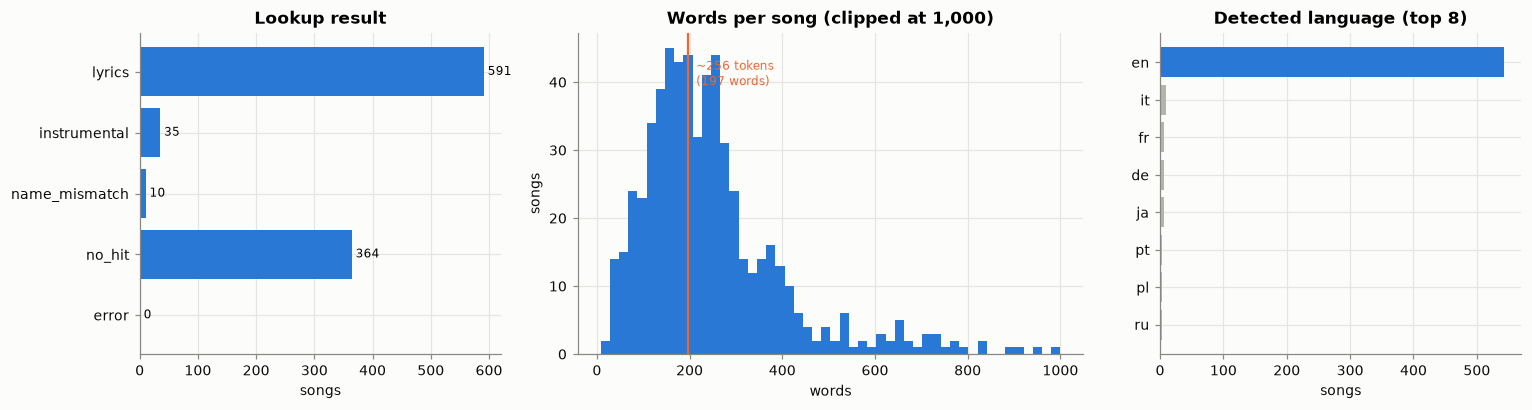

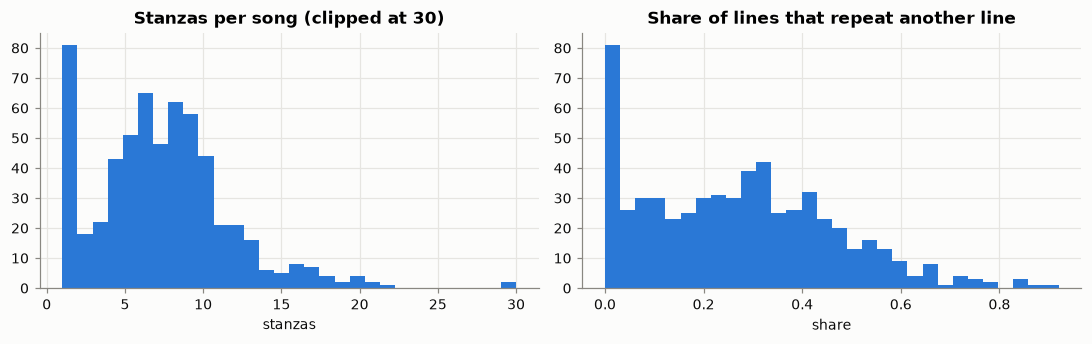

over the 256-token limit (estimated): 55% of songs with lyrics
languages: English 92%; 14 other languages


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1, 1.4, 1]})

axes[0].barh(status_counts.index[::-1], status_counts.values[::-1], color=BLUE)
for y, v in enumerate(status_counts.values[::-1]):
    axes[0].text(v, y, f" {v}", va="center", fontsize=8)
axes[0].set_title("Lookup result")
axes[0].set_xlabel("songs")

limit_words = TOKEN_LIMIT * WORDS_PER_TOKEN
axes[1].hist(has["n_words"].clip(upper=1000), bins=50, color=BLUE)
axes[1].axvline(limit_words, color=ORANGE, lw=1.5)
axes[1].text(limit_words, axes[1].get_ylim()[1] * 0.92, f"  ~{TOKEN_LIMIT} tokens\n  ({limit_words:.0f} words)",
             color=ORANGE, fontsize=8, va="top")
axes[1].set_title("Words per song (clipped at 1,000)")
axes[1].set_xlabel("words")
axes[1].set_ylabel("songs")

top_lang = lang.head(8)
axes[2].barh(top_lang.index[::-1], top_lang.values[::-1], color=[GREY if l != "en" else BLUE for l in top_lang.index[::-1]])
axes[2].set_title("Detected language (top 8)")
axes[2].set_xlabel("songs")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(has["n_stanzas"].clip(upper=30), bins=30, color=BLUE)
axes[0].set_title("Stanzas per song (clipped at 30)")
axes[0].set_xlabel("stanzas")
axes[1].hist(has["repeat_share"], bins=30, color=BLUE)
axes[1].set_title("Share of lines that repeat another line")
axes[1].set_xlabel("share")
plt.tight_layout()
plt.show()
print(f"over the {TOKEN_LIMIT}-token limit (estimated): {(has['est_tokens'] > TOKEN_LIMIT).mean():.0%} of songs with lyrics")
print(f"languages: English {lang.get('en', 0) / len(has):.0%}; {len(lang) - 1} other languages")

**Response.**

**Lookup result.** 59% of songs have lyrics; nearly all the rest returned nothing at all (36%), not a wrong-name candidate. So coverage is limited by what LRCLIB has, not by our matching rule.

**Words per song.** Median 214 words, 10th–90th percentile 92 to 418, right-skewed with a long tail to 1,043. **55% of songs are over the encoder's ~256-token limit** (~197 words). Without splitting, the encoder would only read the first verse or two of most songs, which confirms the stanza split (mean-pooled) is needed.

**Language.** 92% English. The rest is spread thinly over 14 languages.

**Stanzas and repetition.** Median 7 stanzas. 14% of songs have no stanza breaks (see Q5). The median song repeats 27% of its lines (choruses), and a few repeat over 75%. When we mean-pool over stanzas, a repeated chorus counts several times, which may be fine (the chorus is the song's main message) and is worth checking in Milestone 2.

### 7. Perform bi-variate analysis on some of the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables.

share of all English songs mentioning each theme:


,love / desire,night,home / road,death / loss,breakup / leaving,god / religion,fighting / anger,party / dancing,money
%,46.0,36.0,26.0,22.0,22.0,22.0,21.0,17.0,9.0


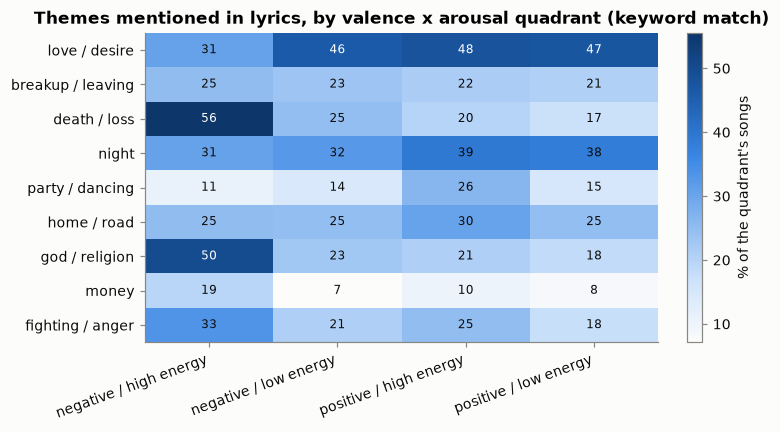

In [36]:
# Quadrant x life theme: what situations do the lyrics talk about?
# Slice by MuSe's lexicon valence x arousal quadrants (fine for exploring, not labels).
en = has[has["language"] == "en"]
LYRIC_THEMES = {
    "love / desire": r"\b(?:love|lover|kiss\w*|heart|darling|desire)\b",
    "breakup / leaving": r"\b(?:goodbye|leave|leaving|left me|gone|over now|let you go|walk away)\b",
    "death / loss": r"\b(?:die|died|dying|death|dead|grave|funeral)\b",
    "night": r"\b(?:night|midnight|tonight|dark|moon)\b",
    "party / dancing": r"\b(?:party|dance|dancing|club|drink\w*|drunk)\b",
    "home / road": r"\b(?:home|road|highway|drive|driving|train|town)\b",
    "god / religion": r"\b(?:god|lord|jesus|heaven|hell|pray\w*|soul)\b",
    "money": r"\b(?:money|cash|rich|dollars?|paid)\b",
    "fighting / anger": r"\b(?:fight|kill\w*|blood|war|hate|rage)\b",
}
text = en["lyrics"].str.lower()
theme_hits = pd.DataFrame({t: text.str.contains(p) for t, p in LYRIC_THEMES.items()})
print("share of all English songs mentioning each theme:")
display((theme_hits.mean() * 100).round(0).sort_values(ascending=False).to_frame("%").T)
share = (theme_hits.groupby(en["quadrant"]).mean() * 100).T
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(share.values, cmap=BLUES, aspect="auto")
ax.set_xticks(range(share.shape[1]), share.columns, rotation=20, ha="right")
ax.set_yticks(range(share.shape[0]), share.index)
ax.grid(False)
for i, j in np.ndindex(share.shape):
    ax.text(j, i, f"{share.values[i, j]:.0f}", ha="center", va="center", fontsize=8,
            color="white" if share.values[i, j] > 45 else INK)
fig.colorbar(im, ax=ax, label="% of the quadrant's songs", fraction=0.04)
ax.set_title("Themes mentioned in lyrics, by valence x arousal quadrant (keyword match)")
plt.tight_layout()
plt.show()

In [35]:
# Valence/arousal quadrant x vocabulary: which words are typical of each quadrant's lyrics?
# The ~10 dimensions aren't fixed yet and 1,000 songs are too few per seed, so we slice by MuSe's
# lexicon quadrants (fine for exploring, though we don't use those scores as labels).
LYRIC_STOP = STOP | set("""oh ooh yeah hey na la da baby gonna wanna gotta ain't i'll you're can't won't
it's that's there's let's i'd you'll we're they're don't cause 'cause like know got get make take""".split())


def song_words(t):  # each word counted once per song, so a repeated chorus doesn't dominate
    return set(w for w in re.findall(r"[a-z']+", t.lower()) if w not in LYRIC_STOP and len(w) > 2)


per_quad = {q: Counter(w for t in grp for w in song_words(t)) for q, grp in en.groupby("quadrant")["lyrics"]}
n_songs = en["quadrant"].value_counts()
all_counts = sum(per_quad.values(), Counter())


def log_odds(q, k=10, min_songs=8):
    """Words most typical of quadrant q vs the rest (log-odds ratio with +1 smoothing)."""
    c, n_q = per_quad[q], n_songs[q]
    n_rest = len(en) - n_q
    score = {w: np.log((c[w] + 1) / (n_q - c[w] + 1)) - np.log((all_counts[w] - c[w] + 1) / (n_rest - all_counts[w] + c[w] + 1))
             for w in c if all_counts[w] >= min_songs}
    return ", ".join(sorted(score, key=score.get, reverse=True)[:k])


pd.DataFrame({"songs": n_songs, "most typical words (log-odds vs other quadrants)": {q: log_odds(q) for q in n_songs.index}})

,songs,most typical words (log-odds vs other quadrants)
positive / low energy,228,"thin, pushed, magic, trees, feelings, state, awake, clear, couple, knows"
negative / low energy,154,"here's, ice, often, stranger, drinking, fucking, locked, trick, wash, desert"
positive / high energy,125,"calling, legs, later, insane, bury, secret, forward, mad, goin', laying"
negative / high energy,36,"death, flesh, hell, falls, passed, business, within, loving, return, school"


In [34]:
# Genre x coverage and genre x length
g = lyr[lyr["genre"].isin(top_genres)]
order = g.groupby("genre")["found"].mean().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(order, g.groupby("genre")["found"].mean()[order] * 100, color=BLUE)
axes[0].axvline(lyr["found"].mean() * 100, color=MUTED, lw=1, ls="--")
axes[0].set_title("Share with lyrics, top 10 genres (dashed = all songs)")
axes[0].set_xlabel("% of songs")
h = has[has["genre"].isin(top_genres)]
order2 = h.groupby("genre")["n_words"].median().sort_values().index
axes[1].boxplot([h.loc[h["genre"] == x, "n_words"] for x in order2], orientation="horizontal", showfliers=False)
axes[1].set_yticks(range(1, len(order2) + 1), order2)
axes[1].axvline(limit_words, color=ORANGE, lw=1.5)
axes[1].set_title("Words per song by genre (orange = token limit)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()
(h.assign(over=h["est_tokens"] > TOKEN_LIMIT).groupby("genre")
  .agg(songs=("n_words", "size"), median_words=("n_words", "median"), share_over_limit=("over", "mean"))
  .sort_values("median_words").round(2).T)

genre,ambient,folk,electronic,alternative,jazz,indie,rock,pop,soul,hip-hop
songs,1.0,18.00,27.00,20.0,8.00,58.00,52.0,60.00,17.00,20.0
median_words,62.0,156.00,162.00,172.0,178.00,210.50,211.5,258.50,281.00,592.0
share_over_limit,0.0,0.39,0.41,0.4,0.38,0.52,0.6,0.68,0.82,1.0


**Response.**

**1. Quadrant × life themes** (picked because users will describe what happened to them, not a mood).
- We would like our users to be able to write things like *"I just broke up"* or *"my dog died"*, as in EmpatheticDialogues.
- Overall: love / desire is in 46% of songs, night 36%, home / road 26%, breakup / leaving 22%, death / loss 22%.
- **Negative / high energy** songs mention death / loss (56%), god / religion (50%) and fighting (33%) far more than other quadrants: this is the metal and industrial share of MuSe.
- **Positive / high energy** songs mention party / dancing most (26%).
- **Breakup / leaving is flat** (21–25%) across quadrants. Breakup songs can be sad, angry or defiant, so a breakup can't be placed in a single valence/arousal corner.
- Situations users are likely to bring up (*breakup*, *death / loss*, *home / road*) each appear in a fifth or more of songs. So lyrics can supply situation-type dimensions (e.g. heartbreak) that the seeds, which are mood words only, lack.

**2. Quadrant × vocabulary** (picked to see whether the words themselves carry mood). With ~36–228 English songs per quadrant, the most typical words are noisy. Only **negative / high energy** is clear: *death, flesh, hell, passed*. The others mix moodful words (*magic, feelings* for positive / low energy) with chance words (*thin, pushed*). **A word-level mood signal is visible but weak at this sample size.** The full fetch (~49,000 songs) and the trained head are what will tell.

**3. Genre × coverage and genre × length** (picked because Q4 showed coverage depends on genre). Ambient, jazz and electronic lose most songs, as instrumentals or absent from LRCLIB. Length varies a lot by genre: **hip-hop** has a median of 592 words and **all** of its 20 songs are over the limit, and soul (281 words, 82% over) and pop (259, 68%) follow. Folk, electronic and alternative are shortest (156–172 words, ~40% over).

### 8. Provide relevant summary statistics for the features you're planning to use. Briefly explain why you may or may not use certain variables.

In [37]:
display(has[["n_words", "n_lines", "n_stanzas", "repeat_share", "est_tokens"]]
        .describe(percentiles=[.1, .5, .9, .99]).round(2))
display(lyr["status"].value_counts(normalize=True).round(3).to_frame("share").T)
display(has["language"].value_counts().head(5).to_frame("songs").T)
usable = has[has["language"] == "en"]
print(f"usable for the song model (English lyrics): {len(usable)} of {len(lyr)} sampled songs ({len(usable) / len(lyr):.0%})")

,n_words,n_lines,n_stanzas,repeat_share,est_tokens
count,591.00,591.00,591.00,591.00,591.00
mean,245.93,38.40,7.12,0.27,319.70
std,156.40,19.84,4.48,0.20,203.32
min,8.00,1.00,1.00,0.00,10.40
10%,92.00,17.00,1.00,0.00,119.60
50%,214.00,35.00,7.00,0.27,278.20
90%,418.00,65.00,12.00,0.53,543.40
99%,798.90,98.20,20.00,0.77,1038.57
max,1043.00,121.00,35.00,0.92,1355.90


status,lyrics,no_hit,instrumental,name_mismatch
share,0.591,0.364,0.035,0.01


language,en,it,fr,de,ja
songs,543,9,6,6,6


usable for the song model (English lyrics): 543 of 1000 sampled songs (54%)


**Response.**

The tables above give length, lines, stanzas, repetition and estimated tokens for songs with lyrics, the lookup result shares, and the top languages.

| Decision | Feature | Why |
|---|---|---|
| **Use (model input)** | `lyrics` | The song model's input. Split into stanzas (or 8-line blocks when there are no stanza breaks), embed each, mean-pool |
| **Use (filter)** | `status`, `language` | Keep only `status == "lyrics"` and English: 54% of songs |
| **Use (EDA / checks)** | `n_words`, `est_tokens`, `n_stanzas` | Size the stanza split; 55% of songs are over the 256-token limit |
| **Use (bookkeeping)** | `lrclib_id`, `lrclib_*` names | Trace each song back to its LRCLIB entry; hand-check matches |
| **Explore later** | `repeat_share` | Whether repeated choruses should count once or several times in pooling |
| **Don't use as labels** | `quadrant` | Built from MuSe's lexicon scores, which we rejected as labels (MuSe section). Only for slicing the EDA |

**Decisions from this EDA:**
- **LRCLIB alone is enough.** ~54% usable is ~49,000 songs in the full catalogue. We don't need the Genius fallback for now.
- **The stanza split is required**, with a fixed-block fallback for the 14% of songs without stanza breaks.
- **The catalogue leans popular, vocal and pop/rock.** Ambient and electronic moods will be thin; check per-dimension song counts once the dimensions are fixed.

## Draft mood dimensions (rough)

Rough work. The aim is to see whether we can get a small set of named mood dimensions that make sense, and whether the two datasets can agree on them: a dimension needs prompts from EmpatheticDialogues *and* songs from MuSe.

As a first step, the cell below collects every candidate term from both datasets into one list (`mood_labels.csv`): the MuSe seeds, the EmpatheticDialogues labels, and the most distinctive words per label. Many distinctive words are topics rather than moods (*ghost*, *pokemon*, *turtle*), so the grouping step must be able to drop terms as well as group them.

In [38]:
# One row per distinct term; `source` says which list(s) it came from.
# (The seeds' co-occurring words are themselves seeds, so they are already covered by muse_seed.)
ed_words = {w for e in ed["emotion"].unique() for w in distinctive(e).split(", ") if w}
labels = (pd.concat([
    pd.DataFrame({"label": seed_counts.index, "source": "muse_seed"}),
    pd.DataFrame({"label": ed["emotion"].unique(), "source": "ed_label"}),
    pd.DataFrame({"label": sorted(ed_words), "source": "ed_distinctive_word"}),
]).groupby("label")["source"].agg("; ".join).reset_index())

LABELS_PATH = Path("../data/interim/mood_labels.csv")
LABELS_PATH.parent.mkdir(parents=True, exist_ok=True)
labels.to_csv(LABELS_PATH, index=False)
print(f"saved {len(labels)} labels to {LABELS_PATH}")
labels["source"].value_counts()

saved 502 labels to ..\data\interim\mood_labels.csv


source
muse_seed                                   258
ed_distinctive_word                         201
ed_label; ed_distinctive_word                22
muse_seed; ed_distinctive_word               11
muse_seed; ed_label; ed_distinctive_word      6
ed_label                                      3
muse_seed; ed_label                           1
Name: count, dtype: int64

#### Coverage per mood (rough exploration)

A first look at the clustered terms in `data/interim/mood_clusters.csv` (502 terms → 16 moods + `unassigned`). We made it by having Claude Opus 5.5 classify every term in the csv generated from the cell above. The mood list, the mapping and these counts will change.

Each MuSe song gets the mood(s) of its seed(s), and each EmpatheticDialogues situation the mood of its label. All 276 seeds and all 32 ED labels are in the file. Song counts are **before** the lyrics filter, which keeps ~54% of songs (see the lyrics section).


In [43]:
# Each MuSe song gets the mood(s) of its seed(s); each ED situation the mood of its label.
clusters = pd.read_csv(INTERIM / "mood_clusters.csv")
to_mood = dict(zip(clusters["label"], clusters["mood"]))
song_moods = muse["seeds"].apply(lambda s: {to_mood[x] for x in s} - {"unassigned"})
n_moods = song_moods.apply(len)
coverage = (pd.DataFrame({"MuSe songs": song_moods.explode().value_counts(),
                          "ED situations": ed["emotion"].map(to_mood).value_counts()})
            .drop(index="unassigned", errors="ignore").fillna(0).astype(int)
            .sort_values("MuSe songs", ascending=False))
print(f"songs with no mood (only unassigned seeds): {(n_moods == 0).sum():,}; "
      f"with more than one mood: {(n_moods > 1).sum():,}")
coverage

songs with no mood (only unassigned seeds): 4,906; with more than one mood: 13,787


,MuSe songs,ED situations
calm,14358,737
ethereal,11209,0
playful,9649,0
nostalgia,8780,1457
excitement,7457,3022
pride,7365,1652
sadness,7028,3153
romance,6838,0
tenderness,6579,2627
dread,6498,0


**Problems**

1. **Five moods have no prompts.** *Ethereal, playful, romance, dread* and *jaded* come only from MuSe seeds: no ED label maps to them. The prompt model can't learn them from ED, so a user could never ask for them.
2. **Shame has almost no songs.** 55 songs, ~30 after the lyrics filter. Too few to train or test the song model on it.
3. **The two sides are unbalanced.** Calm has 14,358 songs but only 737 situations; anxiety has 2,173 songs but 2,961 situations.
4. **Some mappings are debatable.** *Terrified* maps to anxiety although *dread* exists; *jealous* and *disgusted* map to anger.
5. **Songs without a mood.** 4,906 songs (5%) have only `unassigned` seeds: 16 seeds such as *crunchy*, *technical* and *literate*, mostly about sound or style. They can't be labelled.
6. **Too many moods.** 16 is above the ~10 we aimed for, and several overlap (joy / excitement / playful, tenderness / romance, anxiety / dread).

**Potential plan**

1. **Merge the moods that are empty or overlapping**, e.g. dread → anxiety, romance → tenderness, jaded → anger or sadness, playful → joy. Check the merged terms in `mood_clusters.csv` still make sense together.
2. **Drop shame from the song side**, or merge it, and keep it prompt-only if it's needed at all (a song for "I feel ashamed" is probably a sadness song).
3. **Re-check debatable mappings by hand** (a second person, as in the next steps below), especially terrified, jealous and disgusted.
4. **Leave unlabelled songs out of training.** Seed-less songs can still be scored by the trained model and recommended.
5. **Re-count after the lyrics filter** once the full fetch is done. A mood needs enough songs *with English lyrics*, not just enough MuSe songs. Aim for ~10 moods, each with at least a few hundred songs and a few hundred situations.

#### Alternative plan: use the GEMS emotions as the named dimensions

Instead of building our own mood list from the data, we could start from the **Geneva Emotional Music Scale (GEMS)** (Zentner, Grandjean & Scherer, 2008). GEMS is a research scale: the authors asked listeners which emotions music actually makes them feel and found nine: *wonder, transcendence, tenderness, nostalgia, peacefulness, power, joyful activation, tension* and *sadness*.

**Why it's attractive.**
- The dimensions come from published music-psychology research, not from our own grouping, so they are easier to defend.
- Nine dimensions is close to the ~10 we aimed for, and each comes with a set of describing words (e.g. *nostalgia*: nostalgic, dreamy, melancholic, sentimental) that can serve as written definitions for the LLM classification step.

**How it would work.** Keep the same pipeline, but swap the target list: classify every term in `mood_labels.csv` into the nine GEMS emotions (or *drop*) instead of our own moods. The cell below gives a rough preview by remapping the current 16 draft moods onto GEMS, moving a few terms one by one where GEMS splits a draft mood (e.g. *surprised* and *awe* go to wonder, *excited* to joyful activation).

In [44]:
# Rough remap of the 16 draft moods onto the 9 GEMS emotions (Zentner et al., 2008).
# Most draft moods map whole; a few terms are moved one by one where GEMS splits a draft mood.
DRAFT_TO_GEMS = {
    "calm": "peacefulness", "tenderness": "tenderness", "romance": "tenderness",
    "nostalgia": "nostalgia", "sadness": "sadness", "joy": "joyful activation",
    "playful": "joyful activation", "excitement": "power", "pride": "power",
    "ethereal": "transcendence", "anxiety": "tension", "dread": "tension", "anger": "tension",
    "hope": "no GEMS match", "jaded": "no GEMS match", "shame": "no GEMS match",
}
TERM_TO_GEMS = {
    **dict.fromkeys(["amazed", "awe", "blown", "impressed", "impressive", "shock", "shocked", "surprise",
                     "surprised", "unexpected", "mysterious", "enigmatic"], "wonder"),
    **dict.fromkeys(["excited", "animated", "lively", "boisterous", "rambunctious", "stoked", "thrilled"],
                    "joyful activation"),
}
to_gems = {t: TERM_TO_GEMS.get(t, DRAFT_TO_GEMS.get(m, m)) for t, m in to_mood.items()}
song_gems = muse["seeds"].apply(lambda s: {to_gems[x] for x in s} - {"unassigned"})
gems_coverage = (pd.DataFrame({"MuSe songs": song_gems.explode().value_counts(),
                               "ED situations": ed["emotion"].map(to_gems).value_counts()})
                 .drop(index="unassigned", errors="ignore").fillna(0).astype(int)
                 .sort_values("MuSe songs", ascending=False))
print("ED labels with no GEMS match:", sorted(e for e in ed["emotion"].unique() if to_gems[e] == "no GEMS match"))
gems_coverage

ED labels with no GEMS match: ['anticipating', 'ashamed', 'embarrassed', 'guilty', 'hopeful', 'prepared']


,MuSe songs,ED situations
joyful activation,15852,1708
peacefulness,14358,737
tension,13924,7003
power,13204,1652
tenderness,13122,2627
transcendence,10052,0
nostalgia,8780,1457
sadness,7028,3153
no GEMS match,6484,4429
wonder,1343,2084


**What the preview shows.**
1. **Transcendence has no prompts.** It gets 10,052 songs (the *ethereal, spiritual, dreamy* seeds) but no EmpatheticDialogues label maps to it. People don't describe their day as "transcendent", so the prompt model couldn't learn it.
2. **Tension swallows anger and fear.** GEMS has one dimension for both, so *"I'm furious at my boss"* and *"I'm scared about my exam"* would get the same score. With 7,003 situations (28%), it would be the largest prompt dimension by far.
3. **18% of situations have no GEMS match.** Hope (*hopeful, anticipating, prepared*) and shame (*ashamed, embarrassed, guilty*) aren't in GEMS. That's 4,429 situations a user could plausibly type.
4. **Wonder has few songs.** 1,343 before the lyrics filter, so ~700 after.

The gaps come from what GEMS measures: emotions people feel *while listening to music*, not emotions about life events. Our prompts are about life events (*"I just broke up"*), so GEMS fits the song side better than the prompt side.

**Potential plan (if we go with GEMS).**
1. **Use the nine GEMS emotions as the base dimensions** and their describing words as the definitions for the LLM classification.
2. **Split tension into anger and anxiety.** Users clearly separate the two, and both have plenty of songs and situations.
3. **Add hope as an extra dimension** if it has enough songs, since it's common on the prompt side. Fold shame into sadness, as in the main plan.
4. **Keep transcendence as a song-only dimension**, or merge it into wonder or peacefulness. It can't be predicted from prompts, so it would only matter if a user asks for it directly.
5. **Check the coverage table after the lyrics filter**, the same as the main plan.

This would give ~10 dimensions grounded in GEMS, with changes we can justify from our own data.